In [51]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patches
from pathlib import Path
import seaborn as sns

import networkx as nx
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from vizman import viz
viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from src.visualization.one_simple_plot import plot_one_aesthetic_plot

from scipy.stats import entropy
from skimage.measure import shannon_entropy

In [52]:
# # More or less expected 
# portrait, 
# spectral_distance,
# delta_con, 
# edit_distance, # How does it work? 
#     graph edit distance 
#     network mutual information # slightly more noisy 
# wasserstein gromov
# graph kernel networkx 

# # Inverse 
# f1, 
# multiplex layer similarity # looks like f1. What does it do? 
# wasserstein sinkhorn # (behaves exactly the other way in comparoson to wasserstein gromov)
# graph kernel distance # (behaes exactly the other way compared to networkx version)


# # Weird 
# communicability_distance # Prob inverse - but has weird pattern? 
# cosine embedding distance # noise 
# hungarian alignment # noise
# resistance distance # WTF, nearly no information... 
# communicability mse # empty! Or maybe just stupid scaling? 


In [53]:
lecker_red = default_colors["warms"]["LECKER_RED"]
bone_white = default_colors["neutrals"]["BONE_WHITE"]
olive_gray = default_colors["neutrals"]["OLIVE_GRAY"]
halfblack = default_colors["neutrals"]["HALF_BLACK"]

# get the colors for -1 and 1
cmap = default_cmaps["db_bw_lr"].resampled(2)
color_neg1 = cmap(0)
color_pos1 = cmap(1)

black_white_map = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_black_white', 
        [
            bone_white,
            "black",
            # metric_colors[mode], 
            # "white", 
            
        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

In [54]:
dataset_name = "lexis_data" # "suarez_MaMI_dataset"
experiment_name = "03_no_ring_sweeps_animal_0" # "02_ring_sweeps_animal_0" # "01_ring_sweep_animal_0" # "95_ring_seed_100_sweep_animal_206"

base_path = Path(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}")
save_path = base_path / f"all_metrics_for_{experiment_name}.csv"

In [55]:
all_methods = ["f1", 
        "portrait",  
        "communicability", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
        "cosine_embedding", 
        "wasserstein_gromov",
        "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        "graph_kernel", 
        "graph_kernel_networkx", 
        "multiplex_layer_similarity", 
        "resistance_distance", 
        "graph_edit_distance", 
        "network_mutual_information", 
        "communicability_mse", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", 
        "energy"]

method_names = {
    'portrait': 'Portrait Divergence',
    'energy': 'Energy Distance',
    'spectral_distance': 'Spectral Distance',
    'f1': 'F1 Score',
    'communicability': 'Communicability Distance',
    'graph_kernel': 'Graph Kernel Distance',
    'multiplex_layer_similarity': 'Multiplex Layer Similarity',
    'cosine_embedding': 'Cosine Embedding Distance',
    'graph_edit_distance': 'Graph Edit Distance',
    'network_mutual_information': 'Network Mutual Information',
    'hungarian_alignment': 'Hungarian Alignment',
    'graph_kernel_networkx': 'Graph Kernel (NetworkX)',
    'delta_con': 'DeltaCon',
    'resistance_distance': 'Resistance Distance',
    'wasserstein_gromov': 'Wasserstein-Gromov',
    'wasserstein_sinkhorn': 'Wasserstein-Sinkhorn', 

    'edit_distance': 'Edit Distance',
    'communicability_mse': 'Communicability MSE',
    'communicability_jsd': 'Communicability JSD',
    'frobenius': 'Frobenius Distance',
    'jaccard': 'Jaccard Distance'
}

# Individual heatmaps (works like a charm) 
# for m in all_methods:
#     plot_comparison_landscape(m)

# metric_colors = {}
# colors = sns.color_palette("tab20", len(method_names.values()))
# for i, (metric_name, metric_label) in enumerate(zip(method_names.keys(), method_names.values())):
#     metric_colors[metric_name] = colors[i]


In [56]:
matrices_of_metrics = {}

for idx, mode in enumerate(all_methods):

    path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    df = pd.read_csv(path)
    
    # Get the metric column
    metric_col = [col for col in df.columns if col not in ["eta", "gamma", "network_index", "filename", "id"]]
    if not metric_col:
        raise ValueError(f"No metric column found in {df.columns}")

    # Turn df into a pivot table. If there are multiple values for one eta-gamma pair, take the mean
    df_pivot = df.pivot_table(index='gamma', columns='eta', values=metric_col[0], aggfunc='mean')

    # Min-max normalize the values to [0, 1]
    df_pivot = (df_pivot - df_pivot.min().min()) / (df_pivot.max().max() - df_pivot.min().min())
    
    # Store the matrix as a numpy array
    matrix = df_pivot.values[::-1]
    if mode in ["f1", "multiplex_layer_similarity", "jaccard", "communicability_jsd"]: # TODO: WHICH OTHER SIMILARITY METRICS? 
        matrix = 1 - matrix  # Invert for similarity measures
        # mode = "one_minus_" + mode
        
    matrices_of_metrics[mode] = matrix

    # plt.imshow(matrices_of_metrics[mode], cmap='viridis')
    # plt.colorbar(label=f'Normalized {method_names[mode]} Distance')
    # plt.show()
    # break


# Further grid plots

In [57]:
# Add: Averaging over 10 runs! 

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, uniform_filter
from skimage.metrics import structural_similarity as ssim
from skimage.measure import shannon_entropy
import pandas as pd

class VisualQualityAnalyzer:
    """Analyze visual quality and structure of similarity matrices"""
    
    def __init__(self, matrix):
        self.matrix = np.array(matrix, dtype=float)
        
    def calculate_gradient_smoothness(self):
        """Lower = smoother gradients, less noisy"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Variation in gradients indicates noise
        smoothness_score = np.std(grad_y) + np.std(grad_x)
        return smoothness_score
    
    def calculate_total_variation(self):
        """Total variation - lower = smoother"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        tv = np.sum(np.abs(grad_y)) + np.sum(np.abs(grad_x[:, :-1]))
        return tv / self.matrix.size
    
    def calculate_local_coherence(self, window_size=3):
        """Higher = more locally coherent"""
        local_mean = uniform_filter(self.matrix, size=window_size)
        local_sq_mean = uniform_filter(self.matrix**2, size=window_size)
        local_var = local_sq_mean - local_mean**2
        
        # Avoid division by zero
        coherence = 1 / (np.mean(local_var) + 1e-10)
        return coherence
    
    def calculate_snr(self, sigma=2):
        """Signal-to-noise ratio - higher = clearer structure"""
        smoothed = gaussian_filter(self.matrix, sigma=sigma)
        noise = self.matrix - smoothed
        
        signal_power = np.var(smoothed)
        noise_power = np.var(noise)
        
        if noise_power < 1e-10:
            return 100
        
        snr = 10 * np.log10(signal_power / noise_power)
        return snr
    
    def calculate_structure_similarity(self, sigma=5):
        """Similarity to ideal smooth version - higher = better"""
        ideal = gaussian_filter(self.matrix, sigma=sigma)
        
        data_range = self.matrix.max() - self.matrix.min()
        if data_range < 1e-10:
            return 0
            
        score = ssim(self.matrix, ideal, data_range=data_range)
        return score
    
    def calculate_entropy(self):
        """Shannon entropy - for reference"""
        return shannon_entropy(self.matrix)
    
    def calculate_contrast(self):
        """Dynamic range"""
        return self.matrix.max() - self.matrix.min()
    
    def calculate_edge_strength(self):
        """Measure edge clarity using Sobel-like gradients"""
        grad_y = np.diff(self.matrix, axis=0)
        grad_x = np.diff(self.matrix, axis=1)
        
        # Pad to same size
        grad_y = np.pad(grad_y, ((0, 1), (0, 0)), mode='edge')
        grad_x = np.pad(grad_x, ((0, 0), (0, 1)), mode='edge')
        
        # Gradient magnitude
        grad_magnitude = np.sqrt(grad_y**2 + grad_x**2)
        return np.mean(grad_magnitude)
    
    def get_all_metrics(self):
        """Calculate all quality metrics"""
        return {
            'entropy': self.calculate_entropy(),
            'gradient_smoothness': self.calculate_gradient_smoothness(),
            'total_variation': self.calculate_total_variation(),
            'local_coherence': self.calculate_local_coherence(),
            'snr': self.calculate_snr(),
            'structure_similarity': self.calculate_structure_similarity(),
            'contrast': self.calculate_contrast(),
            'edge_strength': self.calculate_edge_strength()
        }
    
    def calculate_composite_quality(self):
        """
        Composite quality score emphasizing visual structure
        Higher = better visual quality
        """
        metrics = self.get_all_metrics()
        
        # Normalize and combine (weights tuned for visual quality)
        score = (
            metrics['snr'] * 0.25 +  # High SNR = clear structure
            metrics['structure_similarity'] * 50 * 0.25 +  # Similar to smooth ideal
            (1 / (metrics['gradient_smoothness'] + 0.1)) * 0.20 +  # Smooth gradients
            metrics['local_coherence'] * 0.15 +  # Locally coherent
            (1 / (metrics['total_variation'] + 0.01)) * 0.15  # Low total variation
        )
        
        return score


def analyze_all_methods(matrices_dict):
    """Analyze all similarity methods"""
    results = {}
    
    for name, matrix in matrices_dict.items():
        
        # min max normalize the matrix
        matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
        analyzer = VisualQualityAnalyzer(matrix)
        results[name] = analyzer.get_all_metrics()
        results[name]['composite_quality'] = analyzer.calculate_composite_quality()
    
    return pd.DataFrame(results).T


def plot_comprehensive_comparison(results_df, metric_colors=None):
    """Plot all metrics for comparison"""
    
    # Metrics to plot
    metrics = [
        'entropy', 'gradient_smoothness', 'total_variation', 'local_coherence',
        'snr', 'structure_similarity', 'contrast', 'composite_quality'
    ]
    
    # Better interpretation labels
    labels = {
        'entropy': 'Entropy\n(lower = more structure)',
        'gradient_smoothness': 'Gradient Smoothness\n(lower = less noisy)',
        'total_variation': 'Total Variation\n(lower = smoother)',
        'local_coherence': 'Local Coherence\n(higher = better)',
        'snr': 'Signal-to-Noise Ratio\n(higher = better)',
        'structure_similarity': 'Structure Similarity\n(higher = better)',
        'contrast': 'Contrast\n(higher = better)',
        'composite_quality': 'Composite Quality Score\n(higher = BETTER)'
    }
    
    # Create subplots
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Sort by metric value for better visualization
        sorted_data = results_df[metric].sort_values()
        
        # Get colors if provided
        if metric_colors:
            colors = [metric_colors.get(name, 'gray') for name in sorted_data.index]
        else:
            colors = 'steelblue'
        
        ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
        ax.set_yticks(range(len(sorted_data)))
        ax.set_yticklabels(sorted_data.index, fontsize=8)
        ax.set_xlabel(labels.get(metric, metric))
        ax.set_title(metric.replace('_', ' ').title())
        ax.grid(axis='x', alpha=0.3)
    
    # Remove empty subplot
    fig.delaxes(axes[-1])
    
    plt.tight_layout()
    # plt.show()
    
    return fig


def rank_methods(results_df, metric='composite_quality'):
    """Rank methods by a specific metric"""
    ranked = results_df.sort_values(metric, ascending=False)
    
    print(f"\n{'='*70}")
    print(f"RANKING BY: {metric.upper()}")
    print(f"{'='*70}")
    print(f"{'Rank':<6} {'Method':<30} {'Score':>10}")
    print(f"{'-'*70}")
    
    for idx, (method, row) in enumerate(ranked.iterrows(), 1):
        print(f"{idx:<6} {method:<30} {row[metric]:>10.4f}")
    
    print(f"{'='*70}\n")
    
    return ranked


In [59]:
# With your actual data
results_df = analyze_all_methods(matrices_of_metrics)

# View full results
print(results_df.round(4))

# Rank by composite quality (should match visual inspection better)
ranked = rank_methods(results_df, 'composite_quality')

# Or rank by specific metrics
rank_methods(results_df, 'snr')  # Signal-to-noise
rank_methods(results_df, 'structure_similarity')  # Smoothness

# Plot everything
# plot_comprehensive_comparison(results_df, metric_colors)

                            entropy  gradient_smoothness  total_variation  \
f1                           9.6291               0.0957           0.0738   
portrait                    11.2877               0.0717           0.0421   
communicability             11.2877               0.2107           0.1616   
delta_con                   11.2877               0.0666           0.0460   
spectral_distance           11.2877               0.0833           0.0453   
edit_distance               11.2869               0.0953           0.0735   
cosine_embedding            11.2877               0.3185           0.2444   
wasserstein_gromov          11.2869               0.1097           0.0815   
wasserstein_sinkhorn        11.2877               0.0926           0.0641   
hungarian_alignment         11.2853               0.3132           0.2417   
graph_kernel                 9.0121               0.0809           0.0557   
graph_kernel_networkx       11.2877               0.0628           0.0428   

,entropy,gradient_smoothness,total_variation,local_coherence,snr,structure_similarity,contrast,edge_strength,composite_quality
graph_kernel_networkx,11.287712,0.062781,0.042810,854.457381,25.297828,0.808727,1.0,0.035705,148.671176
communicability_jsd,11.287712,0.065296,0.042809,809.339106,24.602906,0.804238,1.0,0.035228,141.654918
resistance_distance,11.287712,0.101520,0.015285,846.045837,-11.116177,0.785368,1.0,0.013529,140.869876
delta_con,11.287712,0.066627,0.046026,939.328281,21.948835,0.749898,1.0,0.037332,159.637800
wasserstein_sinkhorn,11.287712,0.092589,0.064069,684.943587,19.843131,0.696506,1.0,0.051421,119.472268
portrait,11.287712,0.071741,0.042083,686.606944,17.372140,0.692842,1.0,0.034746,120.039179
network_mutual_information,11.287712,0.096662,0.061409,563.026333,14.285618,0.677432,1.0,0.049378,99.610797
multiplex_layer_similarity,11.287712,0.094928,0.073136,669.040733,15.804621,0.671448,1.0,0.058275,115.530646
jaccard,11.287712,0.094928,0.073136,669.040728,15.804621,0.671448,1.0,0.058275,115.530646
frobenius,11.286912,0.095264,0.073462,667.140491,15.789701,0.670274,1.0,0.058534,115.218399


In [60]:
# get indices of "ranked" in its ascending order of "snr"
snr_ranked_indices = results_df['snr'].sort_values(ascending=False).index.tolist()

metric_colors = {}
colors = sns.color_palette("tab20", len(method_names.values()))
# for i, (metric_name, metric_label) in enumerate(zip(snr_ranked_indices.keys(), method_names.values())):
#     metric_colors[metric_name] = colors[i]

for i, metric_name in enumerate(snr_ranked_indices):
        metric_colors[metric_name] = colors[i]

In [61]:
len(snr_ranked_indices)

21

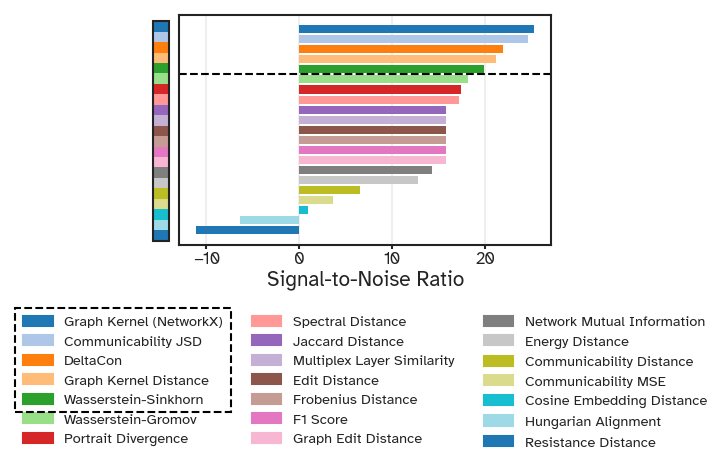

In [62]:
metric = "snr"
labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

fig = plt.figure(figsize=viz.cm_to_inch((9, 6)), dpi=150)
ax = fig.add_axes([0.15, 0.25, 0.7, 0.65])

sorted_data = results_df[metric].sort_values()
colors = [metric_colors.get(name) for name in sorted_data.index]
colors_new = colors.copy()

bars = ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xlabel(labels.get(metric, metric))
# ax.set_title("SNR")
ax.grid(axis='x', alpha=0.3)

# Add colorbar on left side. It should start at the same height as the bars and end at the same height: So get the starting height of the first bar and the ending height of the last bar
bar_height = bars[0].get_height()
start_height = bars[0].get_y() + bar_height
end_height = bars[-1].get_y() + bar_height #    bars[-1].get_height()
# Scale this accordingly to the figure height
start_height = 0.25 + (start_height / len(sorted_data)) * 0.65
end_height = 0.25 + ((end_height + bars[-1].get_height()) / len(sorted_data)) * 0.65
bar_height = (bar_height / len(sorted_data)) * 0.65
# Use this to set the position of the colorbar
# cax = fig.add_axes([0.1, 0.25, 0.03, 0.65])
cax = fig.add_axes([0.1, start_height, 0.03, end_height - start_height - bar_height])
norm = plt.Normalize(vmin=0, vmax=len(sorted_data)-1)
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks([])

# Add legend below - ordered by appearance in barplot (reversed since bars go bottom to top)
handles = [patches.Patch(color=metric_colors[name], label=method_names[name]) 
            for name in reversed(sorted_data.index) if metric_colors]
legend = ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.25), # 0.5, -0.15), 
                    ncol=3, fontsize=7, frameon=False)

# Add horizontal line below the first 5 entries
ax.axhline(y=15.5, color='black', linestyle='--')

# Add a box around the top 5 entries in the legend
fig.canvas.draw()  # Need to draw to get accurate positions

# Get legend box position in figure coordinates
legend_bbox = legend.get_window_extent().transformed(fig.transFigure.inverted())

# Calculate width of one column (ncol=3, so 5 entries = 2 full columns)
col_width = legend_bbox.width / 3
box_width = col_width * 1 # 2  # First 5 entries span ~2 columns

# Create rectangle in figure coordinates
# rect = patches.Rectangle(
#     (legend_bbox.x0 - 0.005, legend_bbox.y0 - 0.005),  # Small padding
#     box_width - 0.03, # + 0.01, 
#     legend_bbox.height + 0.01,
#     # linewidth=1, 
#     edgecolor='black', 
#     facecolor='none',
#     linestyle='--',
#     transform=fig.transFigure, zorder=10
# )

height_legend_box = legend_bbox.height + 0.01

rect = patches.Rectangle(
    (legend_bbox.x0 - 0.005, legend_bbox.y0 + height_legend_box * 2/7), #  - 0.005),  # Small padding
    box_width - 0.03, # + 0.01, 
    height_legend_box*5/7 - 0.005,
    # linewidth=1, 
    edgecolor='black', 
    facecolor='none',
    linestyle='--',
    transform=fig.transFigure, zorder=10
)


fig.patches.append(rect)

plt.show()

# HERE: GOOD PLOT. 

f1
portrait
communicability
delta_con
spectral_distance
edit_distance
cosine_embedding
wasserstein_gromov
wasserstein_sinkhorn
hungarian_alignment
graph_kernel
graph_kernel_networkx
multiplex_layer_similarity
resistance_distance
graph_edit_distance
network_mutual_information
communicability_mse
communicability_jsd
frobenius
jaccard
energy


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/1401574272.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


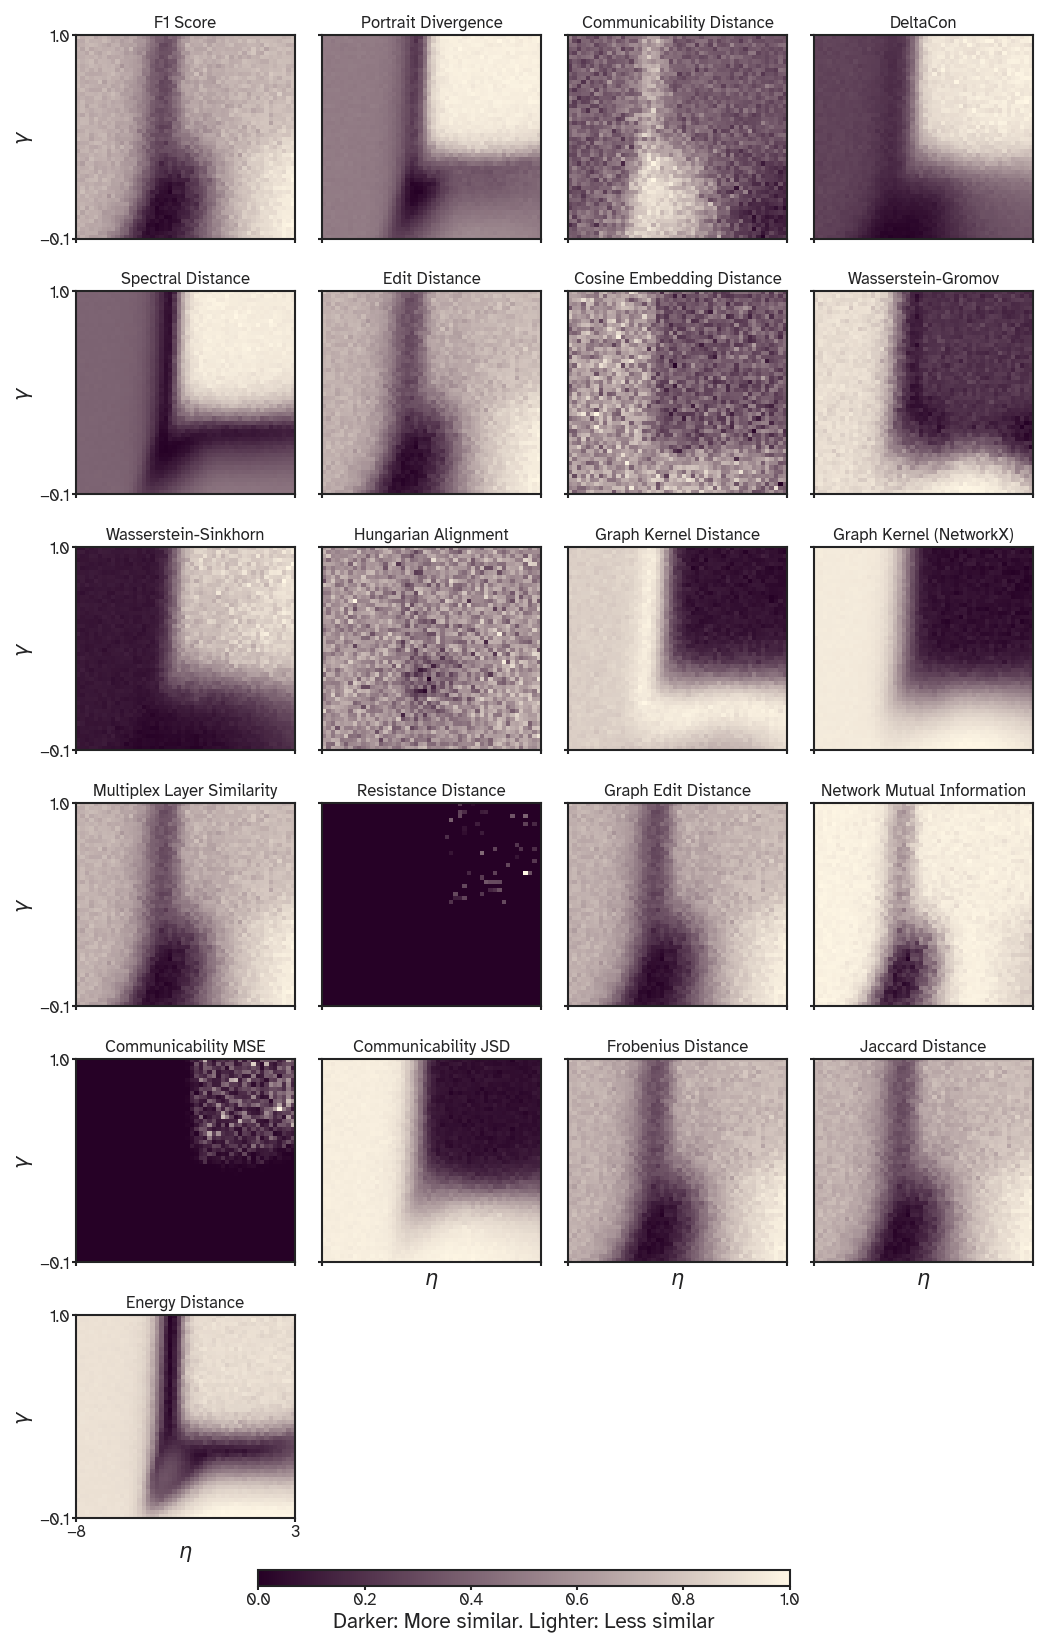

In [63]:
n_methods = len(all_methods)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(all_methods):
    ax = axes[idx]
    
    # matrices_of_metrics[mode]
    # Create scatter plot
    # scatter = ax.scatter(df["eta"], df["gamma"], 
    #                     c=df[metric_col[0]], 
    #                     cmap=default_cmaps["metric_purple_beige"], 
    #                     s=2.4)
    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=default_cmaps["metric_purple_beige"], 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()


f1
portrait
communicability
delta_con
spectral_distance
edit_distance
cosine_embedding
wasserstein_gromov
wasserstein_sinkhorn
hungarian_alignment
graph_kernel
graph_kernel_networkx
multiplex_layer_similarity
resistance_distance
graph_edit_distance
network_mutual_information
communicability_mse
communicability_jsd
frobenius
jaccard
energy


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/2414495481.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


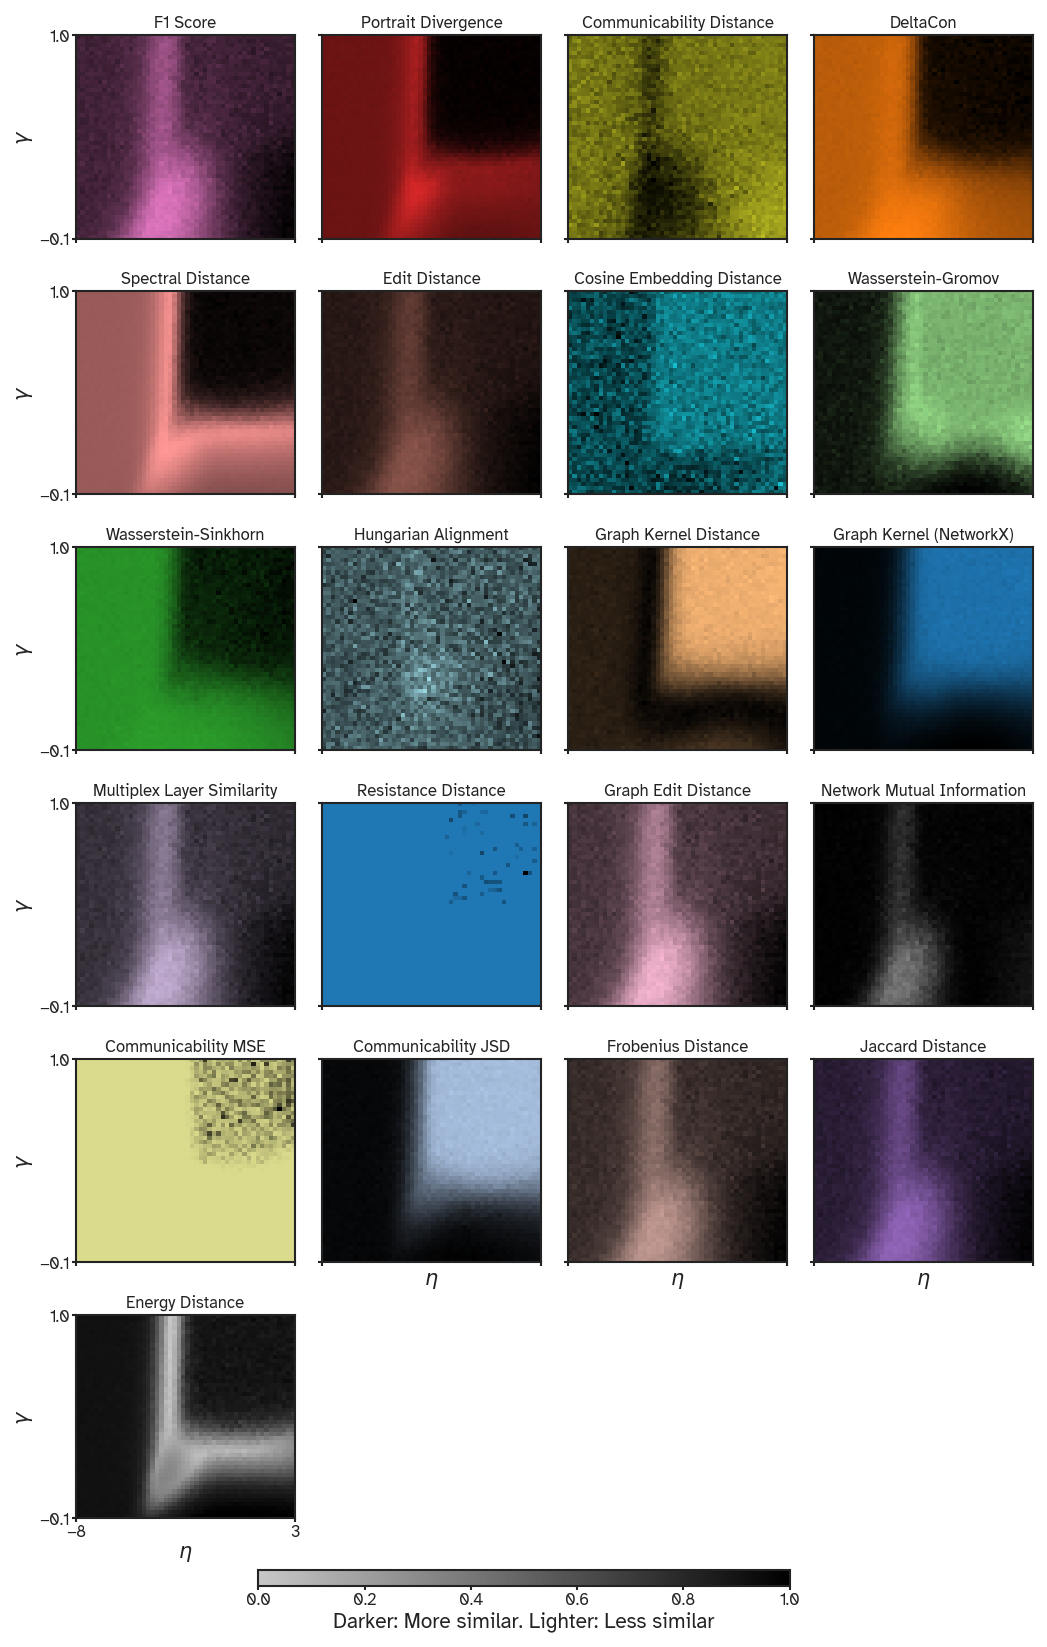

In [64]:
n_methods = len(all_methods)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(all_methods):
    ax = axes[idx]
    
    # matrices_of_metrics[mode]
    # Create scatter plot
    # scatter = ax.scatter(df["eta"], df["gamma"], 
    #                     c=df[metric_col[0]], 
    #                     cmap=default_cmaps["metric_purple_beige"], 
    #                     s=2.4)
    
    # create cmap from metric_colors: going from bone_white to metric_colors[mode]
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [metric_colors[mode], "black"
         # bone_white, 
         ]
    )

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()

energy
f1
portrait
delta_con
spectral_distance
edit_distance
graph_edit_distance
network_mutual_information
wasserstein_gromov
graph_kernel_networkx
communicability_jsd
frobenius
jaccard
multiplex_layer_similarity
cosine_embedding
hungarian_alignment


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/136056241.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


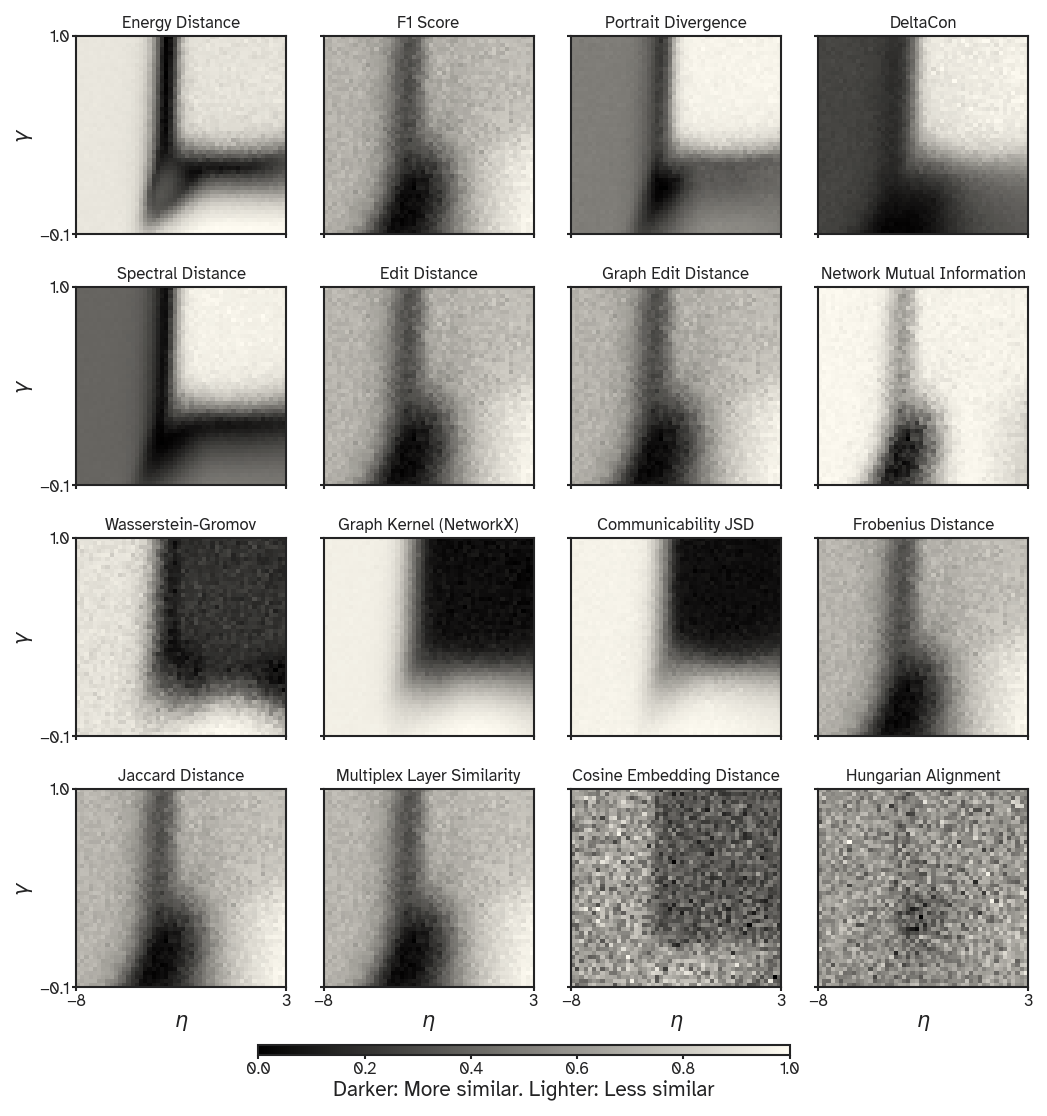

In [65]:
methods_for_gridplot = [
        "energy",
        "f1", # "one_minus_f1", 
        "portrait", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
            "graph_edit_distance", # braucht ewig 
            "network_mutual_information", 
        "wasserstein_gromov",
        "graph_kernel_networkx", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", # one_minus_jaccard", 
         
        
        # "f1", 
        "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
        # "jaccard", 
        # "communicability", 
        "cosine_embedding", 
        # "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        # "graph_kernel", 
        
        # "resistance_distance", 
        
        # "graph_edit_distance", 
        # "network_mutual_information", 
        # "communicability_mse", 
        
        
]
        
n_methods = len(methods_for_gridplot)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(methods_for_gridplot):
    ax = axes[idx]
    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            # "white", 
            bone_white
        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()

energy
f1
portrait
delta_con
spectral_distance
edit_distance
graph_edit_distance
network_mutual_information
wasserstein_gromov
graph_kernel_networkx
communicability_jsd
frobenius
jaccard
multiplex_layer_similarity
cosine_embedding
hungarian_alignment


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/1586738194.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


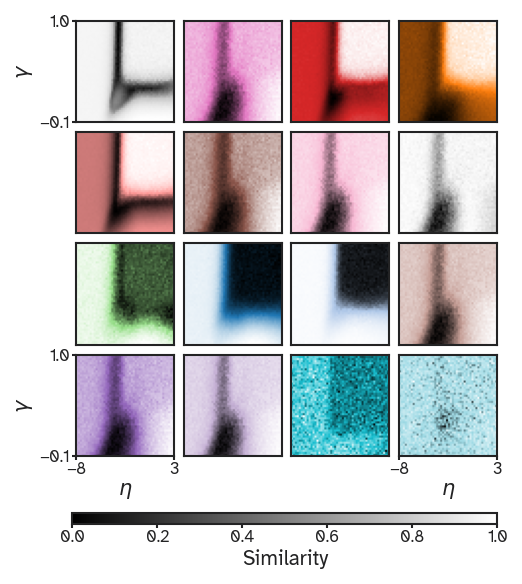

In [66]:
methods_for_gridplot = [
        "energy",
        "f1", # "one_minus_f1", 
        "portrait", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
            "graph_edit_distance", # braucht ewig 
            "network_mutual_information", 
        "wasserstein_gromov",
        "graph_kernel_networkx", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", # one_minus_jaccard", 
         
        
        # "f1", 
        "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
        # "jaccard", 
        # "communicability", 
        "cosine_embedding", 
        # "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        # "graph_kernel", 
        
        # "resistance_distance", 
        
        # "graph_edit_distance", 
        # "network_mutual_information", 
        # "communicability_mse", 
        
        
]
        
n_methods = len(methods_for_gridplot)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 9
# Calculate height to maintain roughly square subplots
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
                            dpi=150,
                            squeeze=True,
                            # sharex=True, 
                            # sharey=True
                            )

axes = axes.flatten()

for idx, mode in enumerate(methods_for_gridplot):
    ax = axes[idx]

    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$")
        ax.set_ylabel(r"$\gamma$")
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$")
    elif idx == len(methods_for_gridplot) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$")
    else: 
        ax.set_yticks([])
        ax.set_xticks([])
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    # ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # # Only add labels to edge subplots
    # if idx % n_cols == 0:  # Left column
    #     ax.set_ylabel(r"$\gamma$")
    # if idx >= n_methods - n_cols:  # Bottom row
    #     ax.set_xlabel(r"$\eta$")

# fig.supxlabel(r"$\eta$")
# fig.supylabel(r"$\gamma$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')


# Get min and max location of the corners of the subplots
x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
y_min = np.min([ax.get_position().y0 for ax in axes])
y_max = np.max([ax.get_position().y1 for ax in axes])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ])
values_for_cbar = np.linspace(0, 1, 256)
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()


plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing
# Or alternatively, use tight_layout with padding:
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

In [67]:
all_methods = methods_for_gridplot

In [68]:
selected_methods = ["energy", "spectral_distance", "portrait", "graph_kernel_networkx", "communicability_jsd"]


# Timing 

number dots: 50000


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/3642144393.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(timing_data,


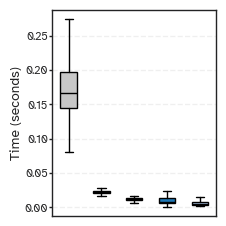

In [69]:
timing_data = []
method_labels = []

for method in selected_methods:
    # Construct the timing file path
    timing_file = Path(base_path) / f"timing_{method}_for_exp_{experiment_name}.csv"
    
    # Check if file exists
    if not timing_file.exists():
        print(f"Warning: File not found - {timing_file}")
        continue
    
    # Read timing data
    df = pd.read_csv(timing_file) # ALL dots! 
    # df = pd.read_csv(timing_file)[:2500]
    
    # Find the timing column
    timing_col = None
    for col in df.columns:
        if any(keyword in col.lower() for keyword in ['time']):
            timing_col = col
            break
    
    # Extract timing values
    timings = df[timing_col].dropna().values
    
    if len(timings) > 0:
        timing_data.append(timings)
        method_labels.append(method_names[method]) # .replace("_", " ").title())

# Order methods by median timing
# if order_by_median:
median_timings = [np.median(data) for data in timing_data]
sorted_indices = np.argsort(median_timings)[::-1]
timing_data = [timing_data[i] for i in sorted_indices]
method_labels = [method_labels[i] for i in sorted_indices]

print("number dots:", len(timing_data[0]))
# Create boxplot
plt.figure(figsize=viz.cm_to_inch((6,6))) # (8, 8))

bp = plt.boxplot(timing_data, 
                labels=method_labels,
                patch_artist=True,
                showmeans=False, # True,
                showfliers=False, # True, # False, 
                ) 

# Customize appearance
for patch, color in zip(bp['boxes'], [metric_colors[method] for method in selected_methods]):
    patch.set_facecolor(color)


# Change median lines to black
for median in bp['medians']:
    median.set_color('black')


plt.ylabel('Time (seconds)') 
plt.xticks([]) 
# # Add grid for better readability
plt.gca().yaxis.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_axisbelow(True)

plt.tight_layout()


# Correlation Matrix 

In [70]:
output_path = Path(base_path) / "ground_truth_analysis"
output_path.mkdir(exist_ok=True)

In [71]:

def load_method_data(method):
    """Load data for a specific method."""
    path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
    try:
        df = pd.read_csv(path)
        metric_cols = [col for col in df.columns 
                      if col not in ["eta", "gamma", "network_index", "filename", "id"]]
        if metric_cols:
            df['metric_value'] = df[metric_cols[0]]
            df['method'] = method
            return df[['eta', 'gamma', 'id', 'metric_value', 'method']]
        return None
    except FileNotFoundError:
        print(f"Warning: File not found for method {method}")
        return None

def calculate_ground_truth(all_data):
    """Calculate approximated ground truth as max across methods for each eta-gamma-id."""
    ground_truth = all_data.groupby(['eta', 'gamma', 'id'])['metric_value'].max().reset_index()
    ground_truth.rename(columns={'metric_value': 'approximated_ground_truth'}, inplace=True)
    return ground_truth

def create_full_dataset(all_data, ground_truth):
    """Create dataset with all methods and ground truth."""
    pivot_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    if ground_truth is not None:
        full_data = pivot_data.merge(ground_truth, on=['eta', 'gamma', 'id'])
    else: 
        full_data = pivot_data
    return full_data

def calculate_correlation_matrix(full_data, methods):
    """Calculate Pearson correlation matrix between methods and ground truth."""
    cols_to_correlate = methods # + ['approximated_ground_truth']
    corr_matrix = full_data[cols_to_correlate].corr(method='pearson')
    return corr_matrix

def cluster_correlation_matrix(corr_matrix):
    """
    Cluster the correlation matrix using hierarchical clustering.
    Returns the reordered correlation matrix and the order of items.
    """
    # Convert correlation to distance
    # Use 1 - correlation for positive correlations (closer to 1 = more similar)
    distance_matrix = 1 - corr_matrix.values
    
    # Ensure all values are non-negative and clip to avoid numerical issues
    distance_matrix = np.clip(distance_matrix, 0, 2)
    
    # Make sure the matrix is symmetric
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    # Set diagonal to 0
    np.fill_diagonal(distance_matrix, 0)
    
    # Convert to condensed distance matrix
    condensed_dist = squareform(distance_matrix, checks=False)
    
    # Replace any NaN or inf values
    condensed_dist = np.nan_to_num(condensed_dist, nan=1.0, posinf=2.0, neginf=0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(condensed_dist, method='average')  # Changed to 'average' which is more robust
    
    # Get the order from the dendrogram
    dendro = dendrogram(linkage_matrix, no_plot=True)
    order = dendro['leaves']

    # Reorder the correlation matrix
    ordered_corr = corr_matrix.iloc[order, order]
    
    return ordered_corr, order, linkage_matrix


In [72]:
print("Loading method data...")
all_data_list = []
loaded_methods = []

for method in all_methods:
    df = load_method_data(method)
    if df is not None:
        all_data_list.append(df)
        loaded_methods.append(method)
        print(f"  ✓ Loaded {method}: {len(df)} rows")

if not all_data_list:
    print("Error: No method data could be loaded!")
    
all_data = pd.concat(all_data_list, ignore_index=True)
print(f"\nCombined data: {len(all_data)} total rows")

print("\nCalculating approximated ground truth...")
# ground_truth = calculate_ground_truth(all_data)
# print(f"  Ground truth calculated for {len(ground_truth)} unique eta-gamma-id combinations")

print("\nCreating full dataset with all methods...")
full_data = create_full_dataset(all_data, ground_truth=None)
# print(f"  Full dataset shape: {full_data.shape}")

# gt_path = output_path / 'approximated_ground_truth.csv'
# ground_truth.to_csv(gt_path, index=False)
# print(f"\n✓ Saved approximated ground truth to {gt_path}")

# full_path = output_path / 'full_dataset_with_ground_truth.csv'
# full_data.to_csv(full_path, index=False)
# print(f"✓ Saved full dataset to {full_path}")

print("\nCalculating Pearson correlation matrix...")
corr_matrix = calculate_correlation_matrix(full_data, loaded_methods)

corr_path = output_path / 'correlation_matrix.csv'
corr_matrix.to_csv(corr_path)
print(f"✓ Saved correlation matrix to {corr_path}")

# print("\nCorrelations with Approximated Ground Truth (Pearson):")
# # gt_corrs = corr_matrix['approximated_ground_truth'].drop('approximated_ground_truth').sort_values(ascending=False)
# # gt_corrs = corr_matrix['approximated_ground_truth'].drop('approximated_ground_truth').sort_values(ascending=False)
# for method, corr in gt_corrs.items():
#     print(f"  {method:30s}: {corr:6.3f}")



Loading method data...
  ✓ Loaded energy: 50000 rows
  ✓ Loaded f1: 50000 rows
  ✓ Loaded portrait: 50000 rows
  ✓ Loaded delta_con: 50000 rows
  ✓ Loaded spectral_distance: 50000 rows
  ✓ Loaded edit_distance: 50000 rows
  ✓ Loaded graph_edit_distance: 50000 rows
  ✓ Loaded network_mutual_information: 50000 rows
  ✓ Loaded wasserstein_gromov: 50000 rows
  ✓ Loaded graph_kernel_networkx: 50000 rows
  ✓ Loaded communicability_jsd: 50000 rows
  ✓ Loaded frobenius: 50000 rows
  ✓ Loaded jaccard: 50000 rows
  ✓ Loaded multiplex_layer_similarity: 50000 rows
  ✓ Loaded cosine_embedding: 50000 rows
  ✓ Loaded hungarian_alignment: 50000 rows

Combined data: 800000 total rows

Calculating approximated ground truth...

Creating full dataset with all methods...

Calculating Pearson correlation matrix...
✓ Saved correlation matrix to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/ground_truth_analysis/correlation_matrix.csv


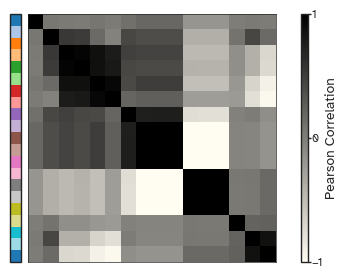

Saved clustered correlation heatmap to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/ground_truth_analysis/correlation_heatmap_clustered.png


In [73]:

def plot_clustered_correlation_heatmap(corr_matrix, save_path):
    """Plot and save clustered correlation matrix heatmap."""
    # Cluster the correlation matrix
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Create figure with dendrogram
    fig = plt.figure(figsize=viz.cm_to_inch((9,9))) # (16, 14)

    
    # Add heatmap
    ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
    sns.heatmap(clustered_corr, annot=False, # True, fmt='.2f', annot_kws={'size': 8},
                cmap=black_white_map, # default_cmaps["db_bw_lr"], # 'RdBu_r', 
                # center=0, vmin=-1, vmax=1, 
                square=True,
                cbar=False, 
                # cbar_kws={'label': 'Pearson Correlation'},
                ax=ax_heatmap, 
                # linewidths=0.5
                )

    # Add spines
    for spine in ax_heatmap.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

    # Get xticklabels, and replace them with their corresponding method names
    method_names_arr = [method_names.get(name, name) for name in clustered_corr.index]
    ax_heatmap.set_yticklabels([]) # method_names_arr) # , rotation=45, ha='right')
    ax_heatmap.set_xticklabels([])# False) # []) # method_names_arr) # , rotation=0)
    # ax_heatmap.set_title('Clustered Correlation Matrix') 
    #                      fontsize=16, pad=20)

    ax_heatmap.set_xlabel(None)
    ax_heatmap.set_ylabel(None)
    
    # Get upper corner of heatmap for positioning dendrogram
    heatmap_pos = ax_heatmap.get_position()
    
    # Add colorbar on left side
    # cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
    cax = fig.add_axes([heatmap_pos.x0 - 0.05, heatmap_pos.y0, 0.03, heatmap_pos.height])
    norm = plt.Normalize(vmin=0, vmax=len(sorted_data)-1)
    sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors), norm=norm)
    cb = plt.colorbar(sm, cax=cax)
    cb.set_ticks([])

    # # Add legend below - ordered by appearance in barplot (reversed since bars go bottom to top)
    # handles = [patches.Patch(color=metric_colors[name], label=name) 
    #             for name in reversed(sorted_data.index) if metric_colors]

    # remove the small "ticks"
    ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

    # cbar
    # Add cbar that is as high as the heatmap. So get the lowest and highest position of the heatmap
    highest_pos = ax_heatmap.get_position().y1
    lowest_pos = ax_heatmap.get_position().y0
    buffer = 0.01
    # cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.8])
    cbar_ax = fig.add_axes([1-buffer, lowest_pos, 0.02, highest_pos - lowest_pos])
    norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
    sm = plt.cm.ScalarMappable(cmap=black_white_map, norm=norm) # default_cmaps["db_bw_lr"], norm=norm)
    sm.set_array([])
    
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Pearson Correlation') # , fontsize=10)
    # only add ticks for -1, 0, 1
    cbar.set_ticks([-1, 0, 1])
    cbar.ax.tick_params(labelsize=8)
    
    # plt.legend(labels=method_names_arr, loc='upper center', # bbox_to_anchor=(0.5, -0.15), 
    #                     ncol=3, fontsize=7, frameon=False)


    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved clustered correlation heatmap to {save_path}")
    
    return clustered_corr

# Clustered correlation heatmap
heatmap_path = output_path / 'correlation_heatmap_clustered.png'
clustered_corr = plot_clustered_correlation_heatmap(corr_matrix, heatmap_path)

# GOOD: DONE HERE


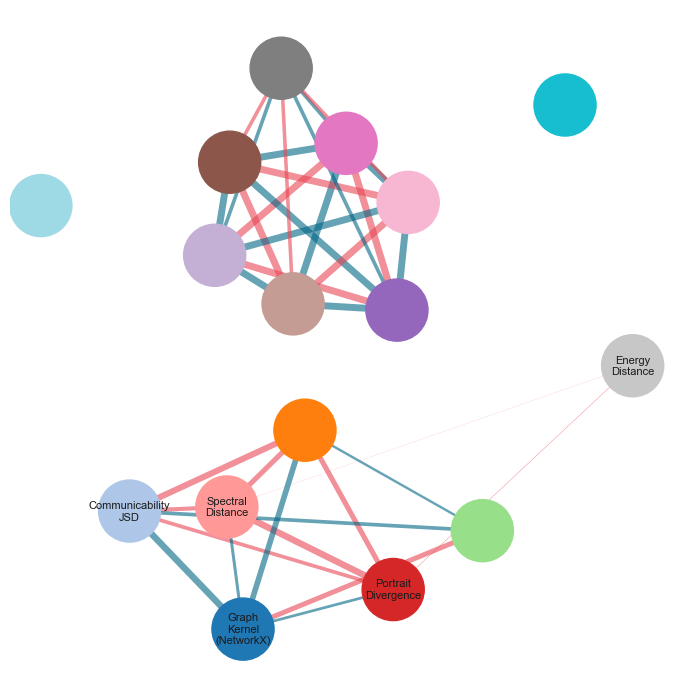

Saved correlation network to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/all_metrics_for_03_no_ring_sweeps_animal_0.csv


In [74]:
from scipy.cluster.hierarchy import fcluster

def plot_correlation_network(corr_matrix, save_path, threshold=0.5):
    """
    Create a network graph where methods are nodes and correlations are edges.
    Uses hierarchical clustering to position nodes.
    """
    # Get clustering information
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Extract communities (adjust t parameter to control number of clusters)
    communities = fcluster(linkage_matrix, t=1.5, criterion='distance')
    
    # Create graph
    G = nx.Graph()
    methods = corr_matrix.columns.tolist()
    G.add_nodes_from(methods)
    
    # Add edges for correlations above threshold
    for i, method1 in enumerate(methods):
        for j, method2 in enumerate(methods):
            if i < j:
                corr_value = corr_matrix.loc[method1, method2]
                if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                    G.add_edge(method1, method2, weight=abs(corr_value), 
                              correlation=corr_value)
    
    # Create community-informed layout
    # First, get positions for each community center
    unique_communities = np.unique(communities)
    n_communities = len(unique_communities)
    
    # Place community centers in a circle
    community_centers = {}
    for i, comm in enumerate(unique_communities):
        angle = 2 * np.pi * i / n_communities
        community_centers[comm] = np.array([np.cos(angle), np.sin(angle)]) * 3


    np.random.seed(0)  # For reproducibility
    # Initialize positions based on community membership
    initial_pos = {}
    for method, comm in zip(methods, communities):
        # Add small random offset within community
        offset = np.random.randn(2) * 0.3
        initial_pos[method] = community_centers[comm] + offset
    
    # Refine with spring layout using community-informed initial positions
    pos = nx.spring_layout(G, pos=initial_pos, k=2, iterations=50, seed=42)
    
    # Create figure
    fig, ax = plt.subplots(figsize=viz.cm_to_inch((18,18)))
    
    # Draw nodes (keep original colors)
    node_colors = [metric_colors[node] for node in G.nodes()]
    node_sizes = [2000 for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=1, ax=ax)
    
    # Draw edges
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    # normalize weights
    weights = (weights - min(weights)) / (max(weights) - min(weights))
    
    correlations = [G[u][v]['correlation'] for u, v in edges]
    edge_widths = [w * 5 for w in weights]
    
    # use the extreme values of this: default_cmaps["db_bw_lr"]
    edge_colors = [color_neg1 if c < 0 else color_pos1 for c in correlations]

    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                          edge_color=edge_colors, ax=ax)
    
    # Draw labels
    labels = {node: method_names[node].replace(' ', '\n').replace('-', '-\n') 
              for node in G.nodes() if node in selected_methods}
    
    nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    ax.axis('off')
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved correlation network to {save_path}")
    
    return G


plot_correlation_network(corr_matrix, save_path, threshold=0.5)

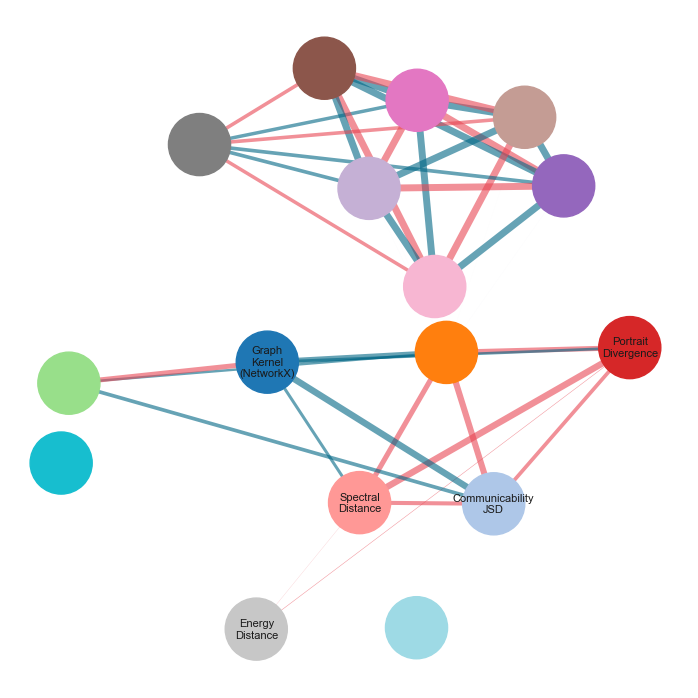

Saved correlation network to /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/all_metrics_for_03_no_ring_sweeps_animal_0.csv


In [75]:
from scipy.cluster.hierarchy import fcluster

def plot_correlation_network(corr_matrix, save_path, threshold=0.5):
    """
    Create a network graph where methods are nodes and correlations are edges.
    Uses hierarchical clustering to position nodes.
    """
    # Get clustering information
    clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)
    
    # Extract communities (adjust t parameter to control number of clusters)
    communities = fcluster(linkage_matrix, t=1.5, criterion='distance')
    
    # Create graph
    G = nx.Graph()
    methods = corr_matrix.columns.tolist()
    G.add_nodes_from(methods)
    
    # Add edges for correlations above threshold
    for i, method1 in enumerate(methods):
        for j, method2 in enumerate(methods):
            if i < j:
                corr_value = corr_matrix.loc[method1, method2]
                if not np.isnan(corr_value) and abs(corr_value) >= threshold:
                    G.add_edge(method1, method2, weight=abs(corr_value), 
                              correlation=corr_value)
    
    # Create community-informed layout
    # First, get positions for each community center
    unique_communities = np.unique(communities)
    n_communities = len(unique_communities)
    
    # Place community centers in a circle
    community_centers = {}
    for i, comm in enumerate(unique_communities):
        angle = 2 * np.pi * i / n_communities
        community_centers[comm] = np.array([np.cos(angle), np.sin(angle)]) * 3
    
    # Initialize positions based on community membership
    initial_pos = {}
    for method, comm in zip(methods, communities):
        # Add small random offset within community
        offset = np.random.randn(2) * 0.3
        initial_pos[method] = community_centers[comm] + offset
    
    # Refine with spring layout using community-informed initial positions
    pos = nx.spring_layout(G, pos=initial_pos, k=2, iterations=50, seed=42)
    
    # Create figure
    fig, ax = plt.subplots(figsize=viz.cm_to_inch((18,18)))
    
    # Draw nodes (keep original colors)
    node_colors = [metric_colors[node] for node in G.nodes()]
    node_sizes = [2000 for node in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=1, ax=ax)
    
    # Draw edges
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    # normalize weights
    weights = (weights - min(weights)) / (max(weights) - min(weights))
    
    correlations = [G[u][v]['correlation'] for u, v in edges]
    edge_widths = [w * 5 for w in weights]
    
    # use the extreme values of this: default_cmaps["db_bw_lr"]
    edge_colors = [color_neg1 if c < 0 else color_pos1 for c in correlations]

    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                          edge_color=edge_colors, ax=ax)
    
    # Draw labels
    labels = {node: method_names[node].replace(' ', '\n').replace('-', '-\n') 
              for node in G.nodes() if node in selected_methods}
    
    nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    ax.axis('off')
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved correlation network to {save_path}")
    
    return G


plot_correlation_network(corr_matrix, save_path, threshold=0.5)

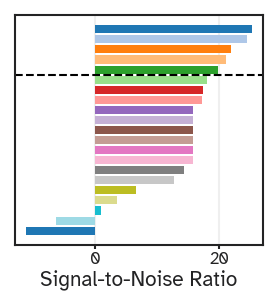

In [76]:
# BUILT FOR 16 networks! 

def plot_comprehensive_comparison(results_df, metric_colors=None):

    """Plot all metrics for comparison"""
    metric = "snr"
    labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

    fig = plt.figure(figsize=viz.cm_to_inch((6,6)), dpi=150)
    ax = fig.add_axes([0.15, 0.25, 0.7, 0.65])
    
    sorted_data = results_df[metric].sort_values()
    colors = [metric_colors.get(name) for name in sorted_data.index]

    bars = ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel(labels.get(metric, metric))
    # ax.set_title("SNR")
    ax.grid(axis='x', alpha=0.3)
    
    
    
    # # Add colorbar on left side
    # cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
    # norm = plt.Normalize(vmin=0, vmax=len(sorted_data)-1)
    # sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors), norm=norm)
    # cb = plt.colorbar(sm, cax=cax)
    # cb.set_ticks([])
    
    
    
    
    # Add legend below - ordered by appearance in barplot (reversed since bars go bottom to top)
    handles = [patches.Patch(color=metric_colors[name], label=name) 
               for name in reversed(sorted_data.index) if metric_colors]
    # legend = ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
    #                   ncol=3, fontsize=7, frameon=False)
    
    # Add horizontal line below the first 5 entries
    ax.axhline(y=15.5, color='black', linestyle='--')
    
    ## Add a box around the top 5 entries in the legend
    ## Get bounding boxes of first 5 legend entries
    # fig.canvas.draw()  # Need to draw to get accurate positions
    
    # texts = legend.get_texts()[:5]
    # patches_list = legend.legend_handles[:5]
    
    # # Get the bounding box that encompasses all 5 entries
    # bboxes = [text.get_window_extent() for text in texts]
    # bboxes += [patch.get_window_extent() for patch in patches_list]
    
    # # Combine all bboxes
    # bbox = bboxes[0]
    # for b in bboxes[1:]:
    #     bbox = bbox.union([b])[0]
    
    # # Transform to legend coordinates and add padding
    # bbox_legend = bbox.transformed(legend.get_transform().inverted())
    
    # # Draw rectangle around the group
    # rect = patches.Rectangle((bbox_legend.x0 - 0.1, bbox_legend.y0 - 0.05), 
    #                          bbox_legend.width + 0.2, bbox_legend.height + 0.1,
    #                          linewidth=1, edgecolor='black', facecolor='none',
    #                          transform=legend.get_transform())
    # ax.add_patch(rect)
    # plt.show()

plot_comprehensive_comparison(results_df, metric_colors)

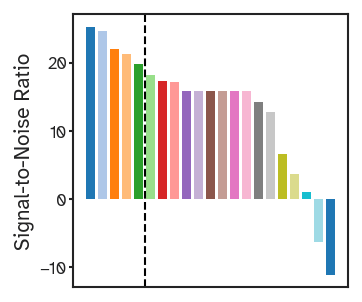

In [77]:
# BUILT FOR 16 networks! (mit plt und ohne subplot) 

def plot_comprehensive_comparison(results_df, metric_colors=None):

    """Plot all metrics for comparison"""
    metric = "snr"
    labels = {'snr': 'Signal-to-Noise Ratio'} # \n(higher = better)'}

    fig = plt.figure(figsize=viz.cm_to_inch((6,6)), dpi=150)
    # ax = fig.add_axes([0.15, 0.25, 0.7, 0.65])
    
    sorted_data = results_df[metric].sort_values()[::-1]
    colors = [metric_colors.get(name) for name in sorted_data.index]

    plt.bar(range(len(sorted_data)), sorted_data.values, color=colors)
    plt.xticks([])  # Remove y-axis ticks

    plt.ylabel(labels.get(metric, metric))
    # plt.title("SNR")
    plt.grid(axis='x', alpha=0.3)

    # Add vertical line below the first 5 entries
    plt.axvline(x=4.5, color='black', linestyle='--')

plot_comprehensive_comparison(results_df, metric_colors)

In [78]:
all_methods_sorted_for_legend = [m for m in snr_ranked_indices if m in all_methods]
all_methods_sorted_for_legend = all_methods_sorted_for_legend[::-1]

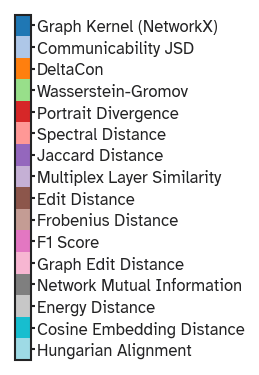

In [79]:
# ONLY COLORBAR + LABELS 


metric = "snr"
labels = {'snr': 'Signal-to-Noise Ratio\n(higher = better)'}

fig = plt.figure(figsize=viz.cm_to_inch((9,9)), dpi=150)
# ax = fig.add_axes([0.15, 0.25, 0.7, 0.65])

colors_for_legend = [metric_colors[m] for m in all_methods_sorted_for_legend]
names_for_legend = [method_names[m] for m in all_methods_sorted_for_legend]
# # bars = ax.barh(range(len(sorted_data)), sorted_data.values, color=colors)
# ax.set_yticks([])  # Remove y-axis ticks
# ax.set_xlabel(labels.get(metric, metric))
# ax.set_title("SNR")
# ax.grid(axis='x', alpha=0.3)

# Add colorbar on left side
cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
norm = plt.Normalize(vmin=0, vmax=len(all_methods_sorted_for_legend))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(
    ticks=[i + 0.5 for i in range(len(names_for_legend))], 
    labels=names_for_legend)


# Add legend below - ordered by appearance in barplot (reversed since bars go bottom to top)
handles = [patches.Patch(color=metric_colors[name], label=name) 
            for name in reversed(sorted_data.index) if metric_colors]
legend = ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                    ncol=3, fontsize=7, frameon=False)

# Add horizontal line below the first 5 entries
ax.axhline(y=15.5, color='black', linestyle='--')

# # Add a box around the top 5 entries in the legend
# for i, text in enumerate(legend.get_texts()[:5]):
#     text.set_bbox(dict(boxstyle='round,pad=0.3', 
#                       edgecolor='black', 
#                       facecolor='none', 
#                       linewidth=1)
#                   )

# # Add a box around the top 5 entries in the legend
# # Get bounding boxes of first 5 legend entries
# fig.canvas.draw()  # Need to draw to get accurate positions

# texts = legend.get_texts()[:5]
# patches_list = legend.legend_handles[:5]

# # Get the bounding box that encompasses all 5 entries
# bboxes = [text.get_window_extent() for text in texts]
# bboxes += [patch.get_window_extent() for patch in patches_list]

# # Combine all bboxes
# bbox = bboxes[0]
# for b in bboxes[1:]:
#     bbox = bbox.union([b])[0]

# # Transform to legend coordinates and add padding
# bbox_legend = bbox.transformed(legend.get_transform().inverted())

# # Draw rectangle around the group
# rect = patches.Rectangle((bbox_legend.x0 - 0.1, bbox_legend.y0 - 0.05), 
#                             bbox_legend.width + 0.2, bbox_legend.height + 0.1,
#                             linewidth=1, edgecolor='black', facecolor='none',
#                             transform=legend.get_transform())
# ax.add_patch(rect)
# plt.show()


graph_kernel_networkx
communicability_jsd
delta_con
wasserstein_gromov
portrait
spectral_distance
jaccard
multiplex_layer_similarity
edit_distance
frobenius
f1
graph_edit_distance
network_mutual_information
energy
cosine_embedding
hungarian_alignment


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/1607521323.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


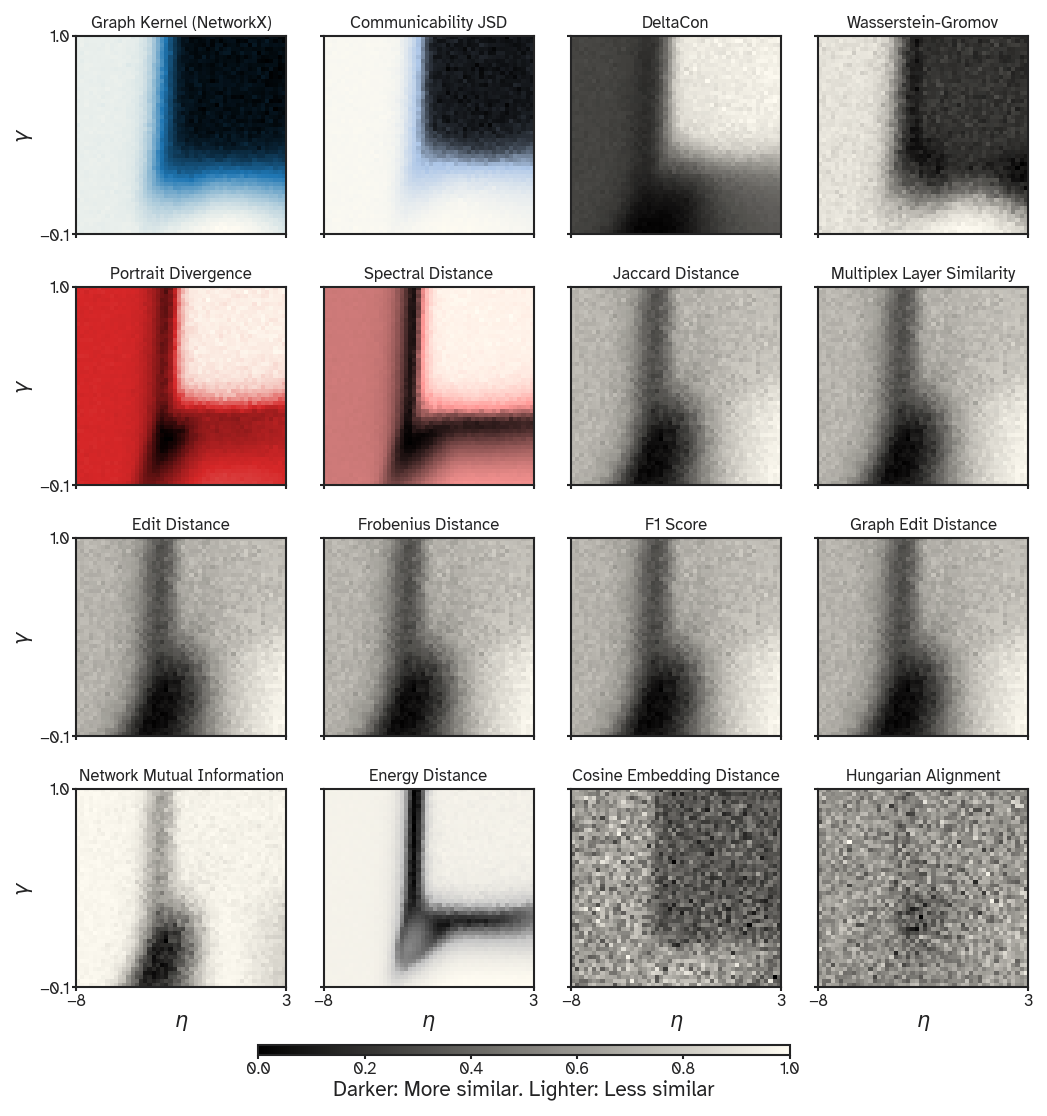

In [80]:
methods_for_gridplot = [
        "energy",
        "f1", # "one_minus_f1", 
        "portrait", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
            "graph_edit_distance", # braucht ewig 
            "network_mutual_information", 
        "wasserstein_gromov",
        "graph_kernel_networkx", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", # one_minus_jaccard", 
         
        
        # "f1", 
        "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
        # "jaccard", 
        # "communicability", 
        "cosine_embedding", 
        # "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        # "graph_kernel", 
        
        # "resistance_distance", 
        
        # "graph_edit_distance", 
        # "network_mutual_information", 
        # "communicability_mse", 
        
        
]
        
n_methods = len(all_methods_sorted_for_legend)
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

# Calculate height to maintain roughly square subplots
height = 18 * (n_rows / n_cols) # * 0.9 # 0.9 is random factor for colorbar

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((18, height)), 
                            dpi=150,
                            sharex=True, 
                            sharey=True)

axes = axes.flatten()

for idx, mode in enumerate(all_methods_sorted_for_legend[::-1]):
    ax = axes[idx]
    
    if mode not in selected_methods:
        cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
            f'custom_cmap_{mode}', 
            [
                "black",
                bone_white
            ]
        )
    else: 
        cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
            f'custom_cmap_{mode}', 
            [
                "black",
                metric_colors[mode], 
                # "white", 
                bone_white
            #  
            #  color_neg1,
            #  halfblack, 
            #  bone_white, 
            ]
        )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
    ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
    
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # Only add labels to edge subplots
    if idx % n_cols == 0:  # Left column
        ax.set_ylabel(r"$\gamma$")
    if idx >= n_methods - n_cols:  # Bottom row
        ax.set_xlabel(r"$\eta$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

# Add one shared colorbar below all subplots
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
plt.tight_layout()

graph_kernel_networkx
communicability_jsd
delta_con
wasserstein_gromov
portrait
spectral_distance
jaccard
multiplex_layer_similarity
edit_distance
frobenius
f1
graph_edit_distance
network_mutual_information
energy
cosine_embedding
hungarian_alignment


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/258270225.py:154: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


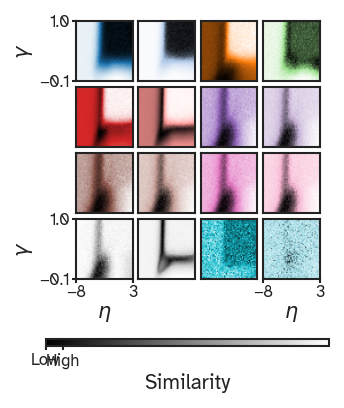

In [81]:
methods_for_gridplot = [
        "energy",
        "f1", # "one_minus_f1", 
        "portrait", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
            "graph_edit_distance", # braucht ewig 
            "network_mutual_information", 
        "wasserstein_gromov",
        "graph_kernel_networkx", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", # one_minus_jaccard", 
         
        
        # "f1", 
        "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
        # "jaccard", 
        # "communicability", 
        "cosine_embedding", 
        # "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        # "graph_kernel", 
        
        # "resistance_distance", 
        
        # "graph_edit_distance", 
        # "network_mutual_information", 
        # "communicability_mse", 
        
        
]
        
n_methods = len(all_methods_sorted_for_legend[::-1])
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
# Calculate height to maintain roughly square subplots
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
                            dpi=150,
                            squeeze=True,
                            # sharex=True, 
                            # sharey=True
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_methods_sorted_for_legend[::-1]):
    ax = axes[idx]

    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$")
        ax.set_ylabel(r"$\gamma$")
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$")
    elif idx == len(methods_for_gridplot) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$")
    else: 
        ax.set_yticks([])
        ax.set_xticks([])
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    # ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # # Only add labels to edge subplots
    # if idx % n_cols == 0:  # Left column
    #     ax.set_ylabel(r"$\gamma$")
    # if idx >= n_methods - n_cols:  # Bottom row
    #     ax.set_xlabel(r"$\eta$")

# fig.supxlabel(r"$\eta$")
# fig.supylabel(r"$\gamma$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')


# Get min and max location of the corners of the subplots
x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
y_min = np.min([ax.get_position().y0 for ax in axes])
y_max = np.max([ax.get_position().y1 for ax in axes])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ])
values_for_cbar = [0,1] # np.linspace(0, 1, 256)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 1], labels=['Low', 'High'])
plt.tight_layout()


plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing
# Or alternatively, use tight_layout with padding:
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

graph_kernel_networkx
communicability_jsd
delta_con
wasserstein_gromov
portrait
spectral_distance
jaccard
multiplex_layer_similarity
edit_distance
frobenius
f1
graph_edit_distance
network_mutual_information
energy
cosine_embedding
hungarian_alignment


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_28967/447171269.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


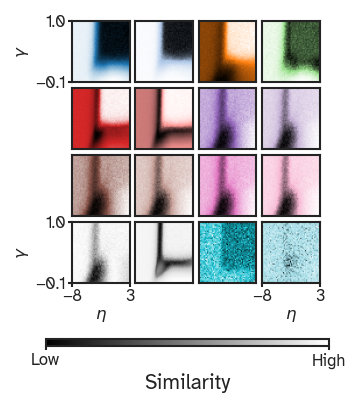

In [82]:
methods_for_gridplot = [
        "energy",
        "f1", # "one_minus_f1", 
        "portrait", 
        "delta_con", 
        "spectral_distance",
        "edit_distance", 
            "graph_edit_distance", # braucht ewig 
            "network_mutual_information", 
        "wasserstein_gromov",
        "graph_kernel_networkx", 
        "communicability_jsd", 
        "frobenius", 
        "jaccard", # one_minus_jaccard", 
         
        
        # "f1", 
        "multiplex_layer_similarity", # one_minus_multiplex_layer_similarity",
        # "jaccard", 
        # "communicability", 
        "cosine_embedding", 
        # "wasserstein_sinkhorn", 
        "hungarian_alignment", 
        # "graph_kernel", 
        
        # "resistance_distance", 
        
        # "graph_edit_distance", 
        # "network_mutual_information", 
        # "communicability_mse", 
        
        
]
        
n_methods = len(all_methods_sorted_for_legend[::-1])
n_cols = 4
n_rows = int(np.ceil(n_methods / n_cols))

image_size_in_cm = 6
fontsize = 8
# Calculate height to maintain roughly square subplots
height = image_size_in_cm * (n_rows / n_cols) 

fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=viz.cm_to_inch((image_size_in_cm, height)), # 18, height)), 
                            dpi=150,
                            squeeze=True,
                            # sharex=True, 
                            # sharey=True
                            )

axes = axes.flatten()

for idx, mode in enumerate(all_methods_sorted_for_legend[::-1]):
    ax = axes[idx]

    
    cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ]
    )
    # cmap = default_cmaps["metric_purple_beige"]

    scatter = ax.imshow(matrices_of_metrics[mode], 
                        cmap=cmap, 
                       aspect='auto',
                    #    origin='lower',
                       extent=[
                           df["eta"].min(), df["eta"].max(),
                           df["gamma"].min(), df["gamma"].max()
                       ])
    
    # ax.set_xlim(-8, 3)
    # ax.set_ylim(-0.1, 1)
    
    # Set ticks
    if (idx % n_cols == 0 and idx // n_cols == n_rows -1): 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == 0: 
        ax.set_yticks([np.ceil(df["gamma"].min()*10)/10, np.floor(df["gamma"].max()*10)/10])
        ax.set_xticks([]) 
        ax.set_ylabel(r"$\gamma$", fontsize=fontsize)
    elif idx == len(methods_for_gridplot) -1: 
        ax.set_yticks([])
        ax.set_xticks([np.ceil(df["eta"].min()*10)/10, np.floor(df["eta"].max()*10)/10])
        ax.set_xlabel(r"$\eta$", fontsize=fontsize)
    else: 
        ax.set_yticks([])
        ax.set_xticks([])
    # Add title for each subplot
    print(mode)
    title = method_names[mode] # f"{metric_col[0].split('subject')[0].replace('_', ' ').capitalize()}"
    # ax.set_title(title, fontsize=8)
    
    # # Add colorbar for each subplot
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.ax.tick_params(labelsize=6)
    
    # # Only add labels to edge subplots
    # if idx % n_cols == 0:  # Left column
    #     ax.set_ylabel(r"$\gamma$")
    # if idx >= n_methods - n_cols:  # Bottom row
    #     ax.set_xlabel(r"$\eta$")

# fig.supxlabel(r"$\eta$")
# fig.supylabel(r"$\gamma$")

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')


# Get min and max location of the corners of the subplots
x_min = np.min([ax.get_position().x0 for ax in axes]) + 0.025
x_max = np.max([ax.get_position().x1 for ax in axes]) + 2 * 0.025
y_min = np.min([ax.get_position().y0 for ax in axes])
y_max = np.max([ax.get_position().y1 for ax in axes])

# Add one shared colorbar below all subplots
cmap = plt.cm.colors.LinearSegmentedColormap.from_list(
        f'custom_cmap_{mode}', 
        [
            "black",
            # metric_colors[mode], 
            "white", 
            # bone_white

        #  
        #  color_neg1,
        #  halfblack, 
        #  bone_white, 
         ])
values_for_cbar = np.linspace(0, 1, 256)
norm = plt.Normalize(vmin=0, vmax=10)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
# cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.01])  # [left, bottom, width, height]
cbar_ax = fig.add_axes([x_min, 0, x_max - x_min, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Similarity") #  (Higher for darker colors)") # Darker: More similar. Lighter: Less similar")
cbar.ax.tick_params(labelsize=8)
cbar.ax.set_xticks([0, 10], labels=['Low', 'High'])
plt.tight_layout()


plt.subplots_adjust(wspace=0.1, hspace=0.1)  # Reduce these values for tighter spacing
# Or alternatively, use tight_layout with padding:
# plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)

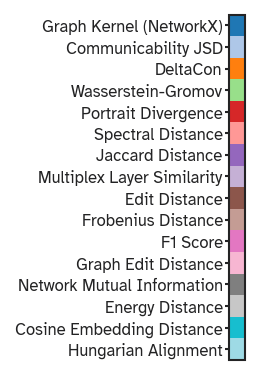

In [83]:
# ONLY COLORBAR + LABELS 

metric = "snr"
labels = {'snr': 'Signal-to-Noise Ratio\n(higher = better)'}

fig = plt.figure(figsize=viz.cm_to_inch((9,9)), dpi=150)

colors_for_legend = [metric_colors[m] for m in all_methods_sorted_for_legend]
names_for_legend = [method_names[m] for m in all_methods_sorted_for_legend]

# Add colorbar on right side (changed from 0.02 to 0.92)
cax = fig.add_axes([0.92, 0.25, 0.03, 0.65])
norm = plt.Normalize(vmin=0, vmax=len(all_methods_sorted_for_legend))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(
    ticks=[i + 0.5 for i in range(len(names_for_legend))], 
    labels=names_for_legend)

cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')

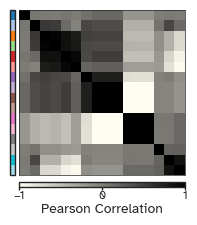

In [84]:

# Cluster the correlation matrix
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Create figure with dendrogram
fig = plt.figure(figsize=viz.cm_to_inch((6,6))) # (16, 14)


# Add heatmap
ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
sns.heatmap(clustered_corr, annot=False, # True, fmt='.2f', annot_kws={'size': 8},
            cmap=black_white_map, # default_cmaps["db_bw_lr"], # 'RdBu_r', 
            # center=0, vmin=-1, vmax=1, 
            square=True,
            cbar=False, 
            # cbar_kws={'label': 'Pearson Correlation'},
            ax=ax_heatmap, 
            # linewidths=0.5
            )

# Add spines
for spine in ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

# Get xticklabels, and replace them with their corresponding method names
method_names_arr = [method_names[method] for method in loaded_methods] 
method_colors_arr = [metric_colors[method] for method in loaded_methods]
# .get(name, name) for name in clustered_corr.index]
ax_heatmap.set_yticklabels([]) # method_names_arr) # , rotation=45, ha='right')
ax_heatmap.set_xticklabels([])# False) # []) # method_names_arr) # , rotation=0)

# new_colors = [metric_colors.get(name) for name in methods_for_gridplot]
# print(corr_matrix.shape, new_colors)
ax_heatmap.set_xlabel(None)
ax_heatmap.set_ylabel(None)

# Get upper corner of heatmap for positioning dendrogram
heatmap_pos = ax_heatmap.get_position()


###############

# Get positions
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1

# Add colorbar on left side

# # cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
# cax = fig.add_axes([heatmap_pos.x0 - 0.05, heatmap_pos.y0, 0.03, heatmap_pos.height])

# norm = plt.Normalize(vmin=0, vmax=len(method_colors_arr))
# sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(method_colors_arr), norm=norm)
# cb = plt.colorbar(sm, cax=cax)
# cb.set_ticks([])
colors_for_legend = [metric_colors[m] for m in all_methods_sorted_for_legend]


cax = fig.add_axes([leftest_pos - 0.04, lowest_pos, 0.02, highest_pos - lowest_pos])
norm = plt.Normalize(vmin=0, vmax=len(all_methods_sorted_for_legend))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(
    ticks=[], 
    # ticks=[i + 0.5 for i in range(len(names_for_legend))], 
    labels=[])# names_for_legend)

cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')


################


# remove the small "ticks"
ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

# cbar
# Add cbar that is as high as the heatmap. So get the lowest and highest position of the heatmap
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1
buffer = 0.01
# cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.8])
# cbar_ax = fig.add_axes([rightest_pos + buffer, lowest_pos, 0.02, highest_pos - lowest_pos])
cbar_ax = fig.add_axes([leftest_pos, lowest_pos - 0.05, rightest_pos - leftest_pos, 0.02]) # highest_pos - lowest_pos])
norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
sm = plt.cm.ScalarMappable(cmap=black_white_map, norm=norm) # default_cmaps["db_bw_lr"], norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation') 

# only add ticks for -1, 0, 1
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=8)

# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
# print(f"Saved clustered correlation heatmap to {save_path}")



# # Clustered correlation heatmap
# heatmap_path = output_path / 'correlation_heatmap_clustered.png'
# clustered_corr = plot_clustered_correlation_heatmap(corr_matrix, heatmap_path)

# # GOOD: DONE HERE


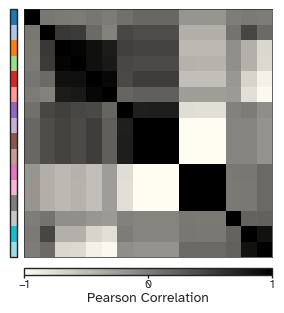

In [85]:

# Cluster the correlation matrix
clustered_corr, order, linkage_matrix = cluster_correlation_matrix(corr_matrix)

# Create figure with dendrogram
fig = plt.figure(figsize=viz.cm_to_inch((9,9))) # (16, 14)


# Add heatmap
ax_heatmap = fig.add_axes([0.22, 0.1, 0.7, 0.8])
sns.heatmap(clustered_corr, annot=False, # True, fmt='.2f', annot_kws={'size': 8},
            cmap=black_white_map, # default_cmaps["db_bw_lr"], # 'RdBu_r', 
            # center=0, vmin=-1, vmax=1, 
            square=True,
            cbar=False, 
            # cbar_kws={'label': 'Pearson Correlation'},
            ax=ax_heatmap, 
            # linewidths=0.5
            )

# Add spines
for spine in ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)

# Get xticklabels, and replace them with their corresponding method names
method_names_arr = [method_names[method] for method in loaded_methods] 
method_colors_arr = [metric_colors[method] for method in loaded_methods]
# .get(name, name) for name in clustered_corr.index]
ax_heatmap.set_yticklabels([]) # method_names_arr) # , rotation=45, ha='right')
ax_heatmap.set_xticklabels([])# False) # []) # method_names_arr) # , rotation=0)

# new_colors = [metric_colors.get(name) for name in methods_for_gridplot]
# print(corr_matrix.shape, new_colors)
ax_heatmap.set_xlabel(None)
ax_heatmap.set_ylabel(None)

# Get upper corner of heatmap for positioning dendrogram
heatmap_pos = ax_heatmap.get_position()


###############

# Get positions
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1

# Add colorbar on left side

# # cax = fig.add_axes([0.02, 0.25, 0.03, 0.65])
# cax = fig.add_axes([heatmap_pos.x0 - 0.05, heatmap_pos.y0, 0.03, heatmap_pos.height])

# norm = plt.Normalize(vmin=0, vmax=len(method_colors_arr))
# sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(method_colors_arr), norm=norm)
# cb = plt.colorbar(sm, cax=cax)
# cb.set_ticks([])
colors_for_legend = [metric_colors[m] for m in all_methods_sorted_for_legend]


cax = fig.add_axes([leftest_pos - 0.04, lowest_pos, 0.02, highest_pos - lowest_pos])
norm = plt.Normalize(vmin=0, vmax=len(all_methods_sorted_for_legend))
sm = plt.cm.ScalarMappable(cmap=plt.cm.colors.ListedColormap(colors_for_legend), norm=norm)
cb = plt.colorbar(sm, cax=cax)
cb.set_ticks(
    ticks=[], 
    # ticks=[i + 0.5 for i in range(len(names_for_legend))], 
    labels=[])# names_for_legend)

cb.ax.yaxis.set_ticks_position('left')
cb.ax.yaxis.set_label_position('left')


################


# remove the small "ticks"
ax_heatmap.tick_params(top=False, right=False, bottom=False, left=False)

# cbar
# Add cbar that is as high as the heatmap. So get the lowest and highest position of the heatmap
highest_pos = ax_heatmap.get_position().y1
lowest_pos = ax_heatmap.get_position().y0

leftest_pos = ax_heatmap.get_position().x0
rightest_pos = ax_heatmap.get_position().x1
buffer = 0.01
# cbar_ax = fig.add_axes([1, 0.1, 0.02, 0.8])
# cbar_ax = fig.add_axes([rightest_pos + buffer, lowest_pos, 0.02, highest_pos - lowest_pos])
cbar_ax = fig.add_axes([leftest_pos, lowest_pos - 0.05, rightest_pos - leftest_pos, 0.02]) # highest_pos - lowest_pos])
norm = plt.Normalize(vmin=clustered_corr.values.min(), vmax=clustered_corr.values.max())
sm = plt.cm.ScalarMappable(cmap=black_white_map, norm=norm) # default_cmaps["db_bw_lr"], norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson Correlation') 

# only add ticks for -1, 0, 1
cbar.set_ticks([-1, 0, 1])
cbar.ax.tick_params(labelsize=8)

# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
# print(f"Saved clustered correlation heatmap to {save_path}")



# # Clustered correlation heatmap
# heatmap_path = output_path / 'correlation_heatmap_clustered.png'
# clustered_corr = plot_clustered_correlation_heatmap(corr_matrix, heatmap_path)

# # GOOD: DONE HERE


In [86]:
def get_top_networks_distribution(dataset_name, experiment_name, mode='portrait', top_n=20):

    # Paths
    base_path = f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{dataset_name}/{experiment_name}"
    summary_path = f"{base_path}/summary_indiv_{mode}_for_exp_{experiment_name}.csv"
    networks_path = f"{base_path}/generated_networks"
    
    # Load summary data
    df = pd.read_csv(summary_path)
    # print(f"Loaded summary with columns: {list(df.columns)}")
    
    # Identify metric column (excluding metadata columns)
    metadata_cols = ["eta", "gamma", "network_index", "filename", "id"]
    metric_cols = [col for col in df.columns if col not in metadata_cols]
    
    if not metric_cols:
        raise ValueError(f"No metric column found in {df.columns}")
    
    metric_col = metric_cols[0]
    print(f"Using metric column: '{metric_col}'")
    
    # Select top N networks (lowest values = best)
    df_sorted = df.nsmallest(top_n, metric_col)
    # print(f"\nSelected top {top_n} networks with {metric_col} range: "
    #       f"[{df_sorted[metric_col].min():.6f}, {df_sorted[metric_col].max():.6f}]")
        
    # Load distance matrix (schaefer) 
    distance_matrix_file = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
    distance_matrix = np.load(distance_matrix_file)
    
    
    # Load networks and calculate degree distributions
    all_degrees = []
    all_distances = []
    
    for idx, row in df_sorted.iterrows():
        # Construct filename
        network_file = Path(networks_path) / row['filename']
        
        # Load network
        network = np.load(network_file)
        
        # Extract adjacency matrix (assuming shape is (1, 100, 100))
        if network.shape[0] == 1:
            adj_matrix = network[0]
        else:
            adj_matrix = network
        
        # Calculate degree for each node
        degrees = np.sum(adj_matrix, axis=1)
        all_degrees.extend(degrees)
        
        # get all distances, remove zeros 
        distances_for_this_network = (distance_matrix*network).flatten()
        all_distances.extend(distances_for_this_network[distances_for_this_network > 0])
        
    # Convert to numpy array
    all_degrees = np.array(all_degrees)
    all_distances = np.array(all_distances)
    # print(f"\nCollected {len(all_degrees)} node degrees from {len(df_sorted)} networks")
    # print(f"Degree statistics: mean={all_degrees.mean():.2f}, "
    #       f"std={all_degrees.std():.2f}, "
    #       f"min={all_degrees.min()}, max={all_degrees.max()}")   

    # Get distance matrix values (excluding zeros on diagonal)
    # all_distances = distance_matrix[distance_matrix > 0]
    
    return all_degrees, all_distances

distributions_degree = {}
distributions_distances = {}
for mode in all_methods: 
    distributions_degree[mode], distributions_distances[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'MaxCrit_subject_0'
Using metric column: 'F1Crit_subject_0'
Using metric column: 'PortraitDiv_subject_0'
Using metric column: 'DeltaCon_exact_subject_0'
Using metric column: 'SpectralDist_normalized_laplacian_subject_0'
Using metric column: 'EditDistance_subject_0'
Using metric column: 'GraphEditDist_subject_0'
Using metric column: 'NMI_standard_subject_0'
Using metric column: 'GW_subject_0'
Using metric column: 'GraphKernel_random_walk_subject_0'
Using metric column: 'CommJSD_subject_0'
Using metric column: 'Frobenius_subject_0'
Using metric column: 'Jaccard_subject_0'
Using metric column: 'MultiplexSim_jaccard_subject_0'
Using metric column: 'CosineEmb_spectral_subject_0'
Using metric column: 'Hungarian_subject_0'


In [87]:

distributions_degree = {}
distributions_distances = {}
for mode in all_methods_sorted_for_legend: #  all_methods: 
    distributions_degree[mode], distributions_distances[mode] = get_top_networks_distribution(dataset_name, experiment_name, mode=mode, top_n=20)


Using metric column: 'Hungarian_subject_0'
Using metric column: 'CosineEmb_spectral_subject_0'
Using metric column: 'MaxCrit_subject_0'
Using metric column: 'NMI_standard_subject_0'
Using metric column: 'GraphEditDist_subject_0'
Using metric column: 'F1Crit_subject_0'
Using metric column: 'Frobenius_subject_0'
Using metric column: 'EditDistance_subject_0'
Using metric column: 'MultiplexSim_jaccard_subject_0'
Using metric column: 'Jaccard_subject_0'
Using metric column: 'SpectralDist_normalized_laplacian_subject_0'
Using metric column: 'PortraitDiv_subject_0'
Using metric column: 'GW_subject_0'
Using metric column: 'DeltaCon_exact_subject_0'
Using metric column: 'CommJSD_subject_0'
Using metric column: 'GraphKernel_random_walk_subject_0'


In [88]:
# Human distributions 
human_connectomes = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/01_connectomes/00_individual_connectomes_bin.npy")
distance_matrix = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy")

all_degrees = []
all_distances = []

for A in human_connectomes: 
    # Calculate degree for each node
    degrees = np.sum(A, axis=1)
    all_degrees.extend(degrees)
    
    # get all distances, remove zeros 
    distances_for_this_network = (distance_matrix*A).flatten()
    all_distances.extend(distances_for_this_network[distances_for_this_network > 0])

# Convert to numpy array
human_degrees = np.array(all_degrees)
human_distances = np.array(all_distances)

distributions_distances['human'] = human_distances
distributions_degree['human'] = human_degrees

human_distances

array([ 44.18144407,  32.06243908,  63.59245238, ..., 116.65333257,
        17.08800749,  16.61324773], shape=(1054270,))

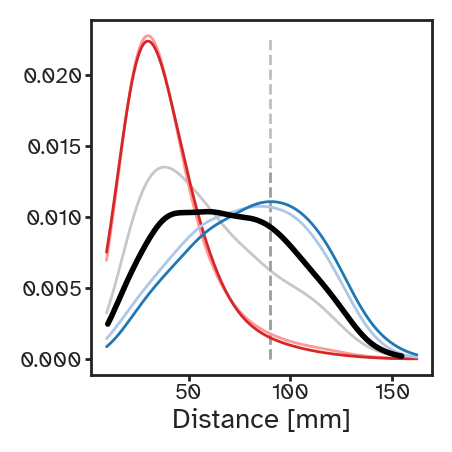

In [89]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

max_value_for_line = 0 

for mode, distances in distributions_distances.items():
    
    if mode not in selected_methods and not mode == 'human': 
        continue
    
    # Create histogram to get counts
    counts, bins = np.histogram(distances, bins=160, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Add padding to bin_centers (linear expansion)
    bin_centers = np.array([bins[0] - (bins[1]-bins[0])*i for i in range(20,0,-1)] + list(bin_centers) + 
                           [bins[-1] + (bins[1]-bins[0])*i for i in range(1,21)])

    # padded_counts = []
    # for count in counts: 
    count = np.array([0]*20 + list(counts) + [0]*20)
    count = ndimage.gaussian_filter1d(count, sigma=10) 
    #     padded_counts.append(count)

    if count.max() > max_value_for_line:
        max_value_for_line = count.max()
        ax.vlines(x=90, 
                  ymin=0, ymax=max_value_for_line, 
                  color="gray", 
                  linestyle='--', alpha=0.5)

    # # Smooth the histogram with Gaussian filter
    # # smoothed_counts = ndimage.gaussian_filter1d(padded_counts, sigma=10) # 2
    
        # Plot smoothed curve
    ax.plot(bin_centers[20:-20], 
            count[20:-20],
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=2 if mode == "human" else 1
            )

plt.xlabel('Distance [mm]')
plt.ylabel("")
# plt.legend(fontsize=8, bbox_to_anchor=(1, 1), frameon=False)
plt.tight_layout()
plt.show()

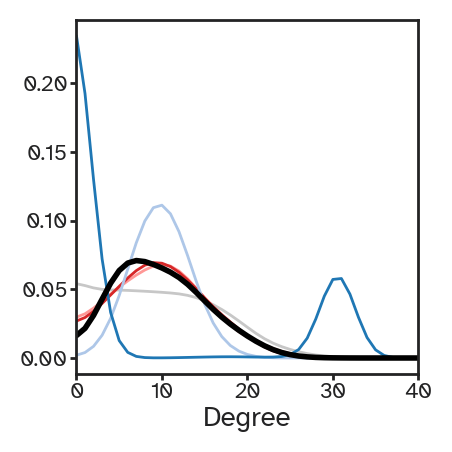

In [90]:
import scipy.ndimage as ndimage

# plot degree distributions (smoothed) 
fig, ax = plt.subplots(figsize=viz.cm_to_inch((6, 6)), dpi=200)

for mode, degrees in distributions_degree.items():
    
    if mode not in selected_methods and not mode == 'human': 
        continue
    
    # Create bins that always have steps of one and start quantity 0
    max_degree = 100
    bins = np.arange(0, max_degree + 2) - 0.5  # bins of width 1 centered on integers
    
    # Create histogram to get counts
    counts, bins = np.histogram(degrees, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    count = ndimage.gaussian_filter1d(counts, sigma=2) 
    
    # Plot smoothed curve
    ax.plot(bin_centers, 
            count,
            label=method_names[mode] if mode != 'human' else 'Human Connectomes',
            color=metric_colors[mode] if mode != 'human' else 'black',
            linewidth=1 if mode != 'human' else 2
            )

plt.xlim(0, 40)
    

plt.xlabel('Degree')
plt.ylabel("")
plt.tight_layout()
plt.show()

# Degeneration

In [91]:
from typing import Dict, List

# Base directory for your chaos analysis results
base_dir = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis"
output_dir = f"{base_dir}/plots"
Path(output_dir).mkdir(parents=True, exist_ok=True)


# degeneration_x_label_descriptor = "Degeneration Level\n(Consensus to Chaos)" # 'Step (0=Consensus -> Max=Chaos)'
# degeneration_x_label_descriptor = "Degeneration: Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'
degeneration_x_label_descriptor = "Increasing Degeneration" # : Consensus to Chaos" # 'Step (0=Consensus -> Max=Chaos)'


In [92]:
## Single degeneration plots 


# def plot_single_metric_chaos(
#     csv_path: str,
#     output_path: str = None,
#     figsize_cm: tuple = (18, 12),
#     show_individual_processes: bool = True,
#     show_mean: bool = True,
#     show_std_band: bool = True,
#     alpha_individual: float = 0.2,
#     title: str = None
# ):
#     """
#     Plot how a single metric changes from consensus to chaos.
#     """
#     # Load data
#     df = pd.read_csv(csv_path)
    
#     # Extract metric name from filename
#     csv_filename = Path(csv_path).stem
#     metric_name = csv_filename.replace('chaos_analysis_', '').replace('_', ' ').title()
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
#     # Get unique process IDs
#     process_ids = sorted(df['process_id'].unique())
    
#     # Plot individual processes
#     if show_individual_processes:
#         for process_id in process_ids:
#             df_process = df[df['process_id'] == process_id].sort_values('step')
#             ax.plot(
#                 df_process['step'],
#                 df_process['metric_value'],
#                 alpha=alpha_individual,
#                 color='gray',
#                 linewidth=1,
#                 zorder=1
#             )
    
#     # Calculate mean and std across processes for each step
#     df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
    
#     # Plot mean trajectory
#     if show_mean:
#         ax.plot(
#             df_summary['step'],
#             df_summary['mean'],
#             color=lecker_red,
#             # linewidth=2.5,
#             # label='Mean trajectory',
#             zorder=3
#         )
    
#     # Plot standard deviation band
#     if show_std_band:
#         ax.fill_between(
#             df_summary['step'],
#             df_summary['mean'] - df_summary['std'],
#             df_summary['mean'] + df_summary['std'],
#             alpha=0.3,
#             color=lecker_red,
#             # label='±1 SD',
#             zorder=2
#         )
    
#     # Formatting
#     ax.set_xlabel(degeneration_x_label_descriptor) # , fontsize=11)
#     ax.set_ylabel(f'{metric_name} Distance') # , fontsize=11)
    
#     if title:
#         ax.set_title(title) # , fontsize=12, fontweight='bold')
#     else:
#         ax.set_title(f'Network Degradation: {metric_name}') # , fontsize=12, fontweight='bold')
    
#     # Add grid
#     ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
#     # Add legend if showing mean/std
#     if show_mean or show_std_band:
#         ax.legend(frameon=False, loc='best')
    
#     # Tight layout
#     plt.tight_layout()
    
#     # Save or show
#     if output_path:
#         plt.savefig(output_path, dpi=300, bbox_inches='tight')
#         print(f"Saved plot to: {output_path}")
#     else:
#         plt.show()
    
#     # plt.close()
#     plt.show()
    
#     return fig, ax



# # Plot individual metrics
# print("Plotting individual metrics...")
# for metric in all_methods:
#     csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
#     if Path(csv_path).exists():
#         output_path = f"{output_dir}/chaos_{metric}.png"
#         plot_single_metric_chaos(
#             csv_path=csv_path,
#             output_path=output_path,
#             figsize_cm=(6,6), 
#             show_individual_processes=True,
#             show_mean=True,
#             show_std_band=True
#         )
#     else:
#         print(f"Warning: {csv_path} not found, skipping...")



Plotting comparison...
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.png


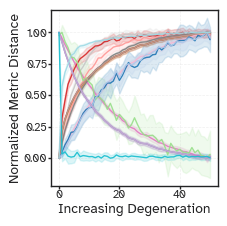

In [93]:
def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True,
    colors: List[str] = None
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    if colors is None:
        colors = sns.color_palette("husl", len(csv_paths))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = colors[idx]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            # linewidth=2,
            label=method_names[metric_name], # tric_name.replace('_', ' ').title(),
            alpha=0.9
        )
        
        # Optional: add std band
        ax.fill_between(
            df_summary['step'],
            df_summary[y_col] - df_summary[std_col],
            df_summary[y_col] + df_summary[std_col],
            alpha=0.15,
            color=color
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    # ax.legend(frameon=False, loc='best', bbox_to_anchor=(1.05, 1))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    # plt.close()
    plt.show()
    
    return fig, ax


# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in all_methods:
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.png",
        figsize_cm=(6,6),
        normalize=True, 
        colors=[metric_colors[metric] for metric in csv_paths.keys()]
    )




Plotting comparison...
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.png


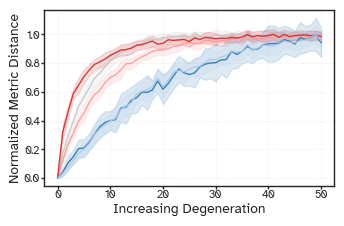

In [94]:
def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (9,6),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = metric_colors[metric_name]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=metric_colors[metric_name], # color,
            # linewidth=2,
            label=method_names[metric_name], # tric_name.replace('_', ' ').title(),
            alpha=0.9
        )
        
        # Optional: add std band
        ax.fill_between(
            df_summary['step'],
            df_summary[y_col] - df_summary[std_col],
            df_summary[y_col] + df_summary[std_col],
            alpha=0.15,
            color=color
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # plt.legend()  
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
    
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in selected_methods: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.png",
        figsize_cm=(9,6), # 6),
        normalize=True
    )



Plotting comparison...
Energy Distance
Spectral Distance
Portrait Divergence
Graph Kernel (NetworkX)
Communicability JSD
Saved comparison plot to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/chaos_analysis/plots/chaos_comparison_all_metrics.png


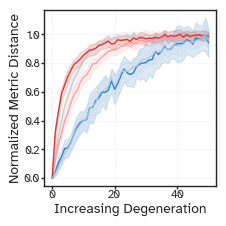

In [95]:
def plot_multiple_metrics_comparison(
    csv_paths: Dict[str, str],
    output_path: str = None,
    figsize_cm: tuple = (20, 12),
    normalize: bool = True
):
    """
    Compare multiple metrics on the same plot.
    """
    fig, ax = plt.subplots(figsize=viz.cm_to_inch(figsize_cm))
    
    for idx, (metric_name, csv_path) in enumerate(csv_paths.items()):
        # Load data
        df = pd.read_csv(csv_path)
        
        # Calculate mean trajectory
        df_summary = df.groupby('step')['metric_value'].agg(['mean', 'std']).reset_index()
        
        # Normalize if requested
        if normalize:
            min_val = df_summary['mean'].min()
            max_val = df_summary['mean'].max()
            if max_val > min_val:  # Avoid division by zero
                df_summary['mean_norm'] = (df_summary['mean'] - min_val) / (max_val - min_val)
                df_summary['std_norm'] = df_summary['std'] / (max_val - min_val)
                y_col = 'mean_norm'
                std_col = 'std_norm'
            else:
                y_col = 'mean'
                std_col = 'std'
        else:
            y_col = 'mean'
            std_col = 'std'
        
        # Plot
        color = metric_colors[metric_name]
        ax.plot(
            df_summary['step'],
            df_summary[y_col],
            color=color,
            label=method_names[metric_name],
            alpha=0.9
        )

        print(method_names[metric_name])
        # Optional: add std band
        ax.fill_between(
            df_summary['step'],
            df_summary[y_col] - df_summary[std_col],
            df_summary[y_col] + df_summary[std_col],
            alpha=0.15,
            color=color
        )
    
    # Formatting
    ax.set_xlabel(degeneration_x_label_descriptor)
    if normalize:
        ax.set_ylabel('Normalized Metric Distance') # , fontsize=11)
    else:
        ax.set_ylabel('Metric Distance')

    # ax.set_title('Comparison of Metrics During Network Degradation', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # plt.legend()  
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plot to: {output_path}")
    else:
        plt.show()
        
    
    # plt.close()
    plt.show()
    
    return fig, ax



# Plot comparison of all metrics
print("\nPlotting comparison...")
csv_paths = {}
for metric in selected_methods: 
    csv_path = f"{base_dir}/chaos_analysis_{metric}.csv"
    if Path(csv_path).exists():
        csv_paths[metric] = csv_path

if csv_paths:
    plot_multiple_metrics_comparison(
        csv_paths=csv_paths,
        output_path=f"{output_dir}/chaos_comparison_all_metrics.png",
        figsize_cm=(6,6), # 6),
        normalize=True
    )


# OLD 

COMPREHENSIVE METHOD EVALUATION

Loading data...
  ✓ Loaded portrait
  ✓ Loaded energy
  ✓ Loaded spectral_distance
  ✓ Loaded f1
  ✓ Loaded communicability
  ✓ Loaded graph_kernel
  ✓ Loaded multiplex_layer_similarity
  ✓ Loaded cosine_embedding
  ✓ Loaded graph_edit_distance
  ✓ Loaded network_mutual_information
  ✓ Loaded hungarian_alignment
  ✓ Loaded graph_kernel_networkx
  ✓ Loaded delta_con
  ✓ Loaded resistance_distance
  ✓ Loaded wasserstein_gromov
  ✓ Loaded wasserstein_sinkhorn

Loaded 16 methods with 50000 networks

STRATEGY 1: CONSENSUS-BASED GROUND TRUTH

Correlations with MEAN consensus:
  portrait                      : 0.4731
  energy                        : 0.9293
  spectral_distance             : 0.4505
  f1                            : -0.3241
  communicability               : -0.0901
  graph_kernel                  : -0.0726
  multiplex_layer_similarity    : -0.3296
  cosine_embedding              : 0.2773
  graph_edit_distance           : 0.3241
  network_mutual_

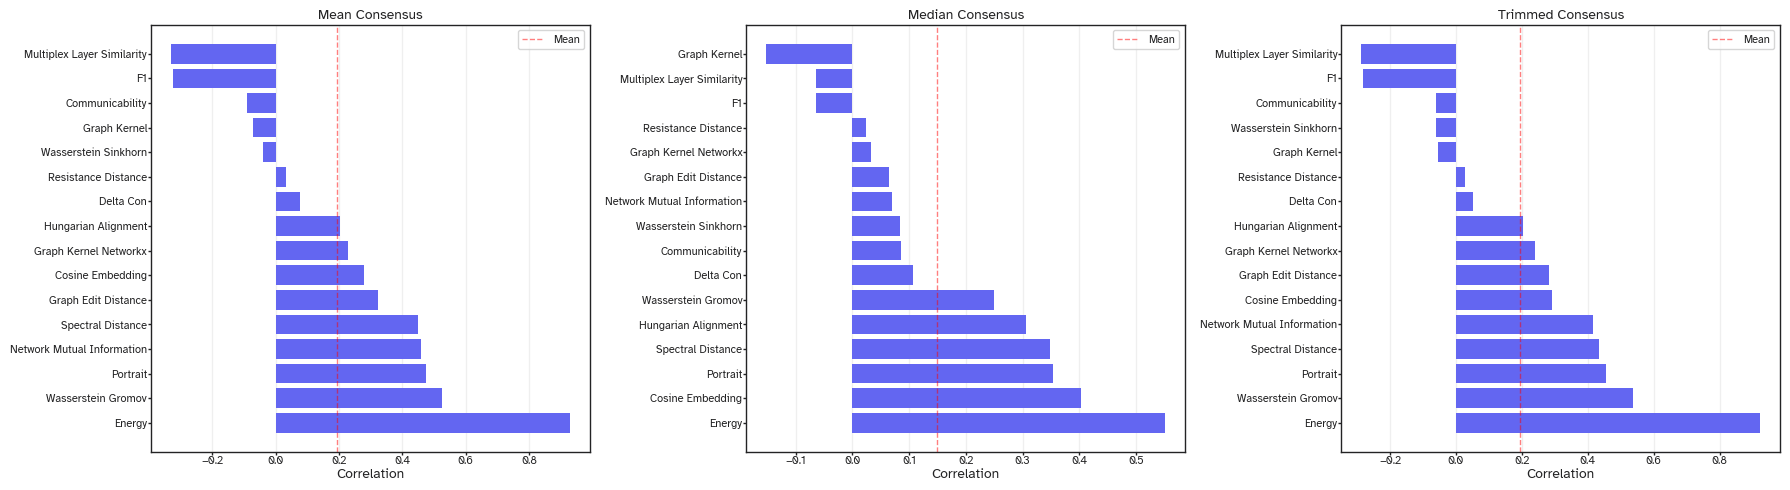


STRATEGY 2: INTER-METHOD AGREEMENT

Average agreement with other methods:
  energy                        : 0.1144
  portrait                      : 0.0613
  spectral_distance             : 0.0578
  network_mutual_information    : 0.0374
  cosine_embedding              : 0.0070
  resistance_distance           : 0.0052
  wasserstein_gromov            : 0.0035
  graph_edit_distance           : -0.0022
  hungarian_alignment           : -0.0032
  delta_con                     : -0.0131
  wasserstein_sinkhorn          : -0.0355
  graph_kernel_networkx         : -0.0655
  communicability               : -0.0689
  graph_kernel                  : -0.1239
  f1                            : -0.1311
  multiplex_layer_similarity    : -0.1326


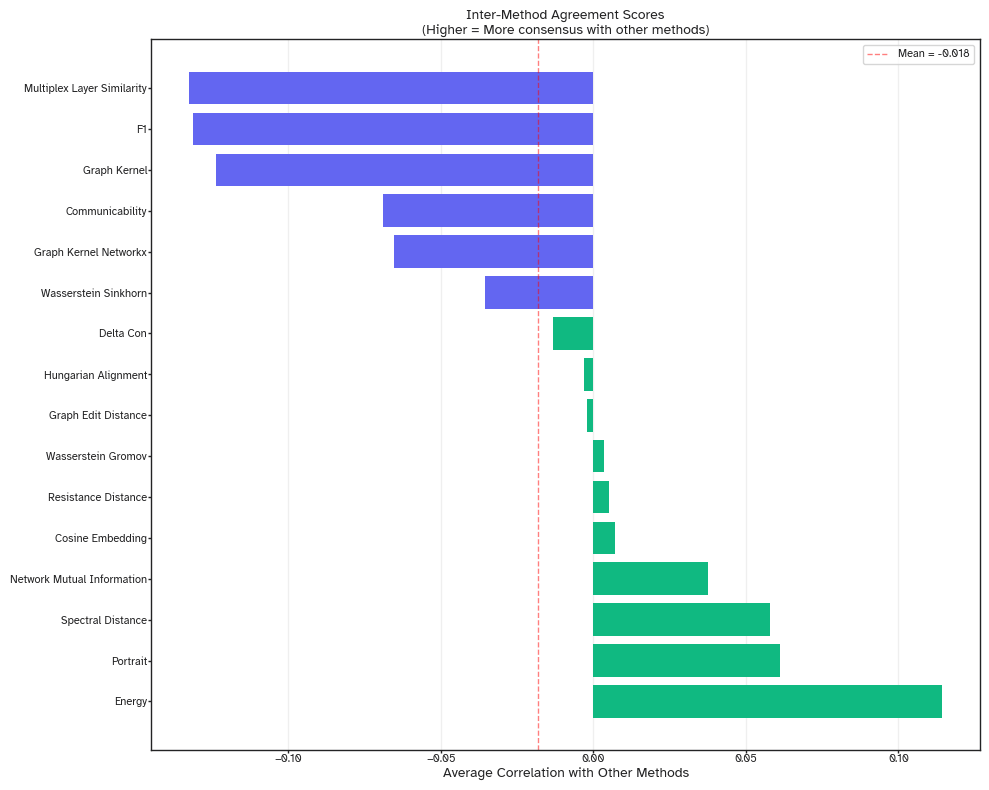


STRATEGY 3: PCA-BASED APPROACH

Explained variance by component:
  PC1: 0.4399 (43.99%)
  PC2: 0.2123 (21.23%)
  PC3: 0.0899 (8.99%)
  PC4: 0.0626 (6.26%)
  PC5: 0.0615 (6.15%)
  Cumulative (first 3): 0.7421

PC1 Loadings (main component):
  delta_con                     :  0.3606 (|0.3606|)
  portrait                      :  0.3390 (|0.3390|)
  spectral_distance             :  0.3322 (|0.3322|)
  graph_kernel                  : -0.3236 (|0.3236|)
  wasserstein_sinkhorn          :  0.3223 (|0.3223|)
  graph_kernel_networkx         : -0.2895 (|0.2895|)
  multiplex_layer_similarity    : -0.2643 (|0.2643|)
  f1                            : -0.2635 (|0.2635|)
  graph_edit_distance           :  0.2635 (|0.2635|)
  network_mutual_information    :  0.2310 (|0.2310|)
  wasserstein_gromov            : -0.2012 (|0.2012|)
  communicability               : -0.1607 (|0.1607|)
  energy                        :  0.1279 (|0.1279|)
  cosine_embedding              : -0.0732 (|0.0732|)
  hungarian_align

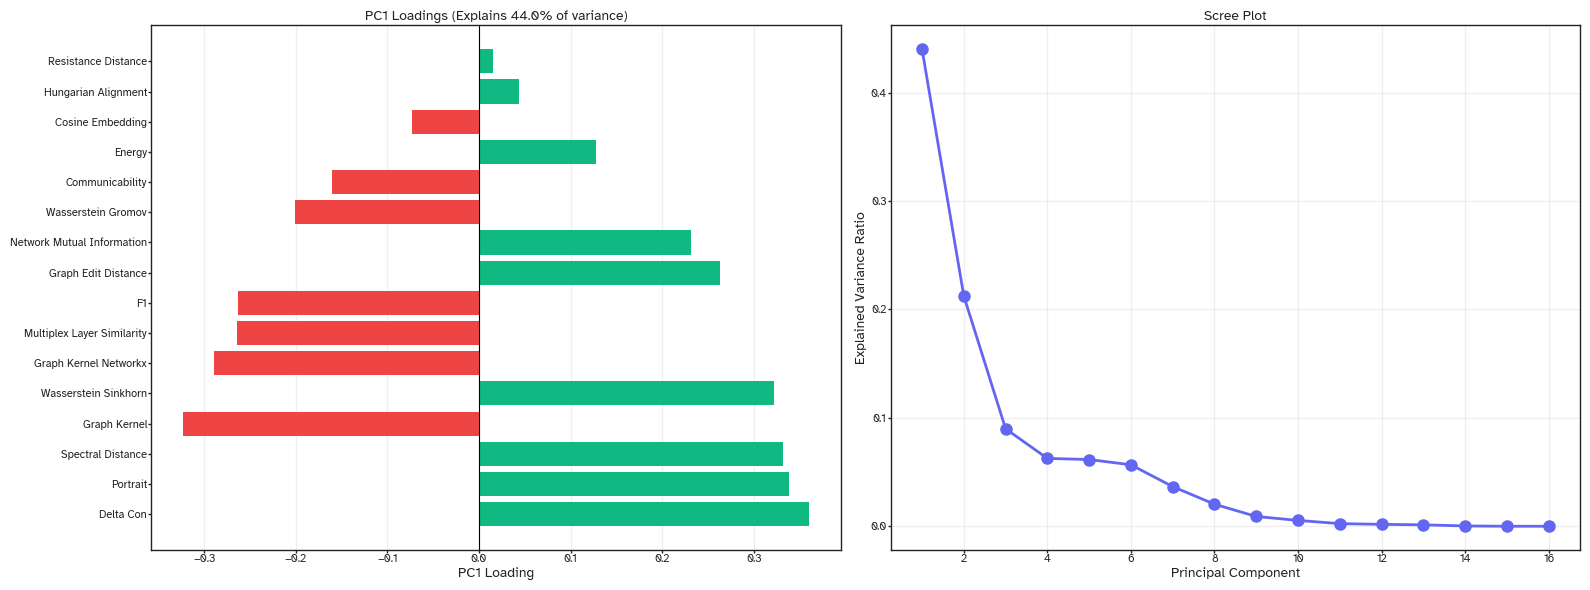


STRATEGY 4: STABILITY ANALYSIS

Stability metrics (lower = more stable/consistent):

Coefficient of Variation (CV):
  network_mutual_information    : 0.1288
  hungarian_alignment           : 0.1948
  cosine_embedding              : 0.2235
  graph_edit_distance           : 0.2652
  communicability               : 0.2707
  wasserstein_gromov            : 0.2872
  energy                        : 0.3204
  portrait                      : 0.3782
  f1                            : 0.3827
  multiplex_layer_similarity    : 0.3982
  graph_kernel                  : 0.4564
  spectral_distance             : 0.5432
  delta_con                     : 0.5573
  graph_kernel_networkx         : 0.6025
  wasserstein_sinkhorn          : 0.6837
  resistance_distance           : 38.6465


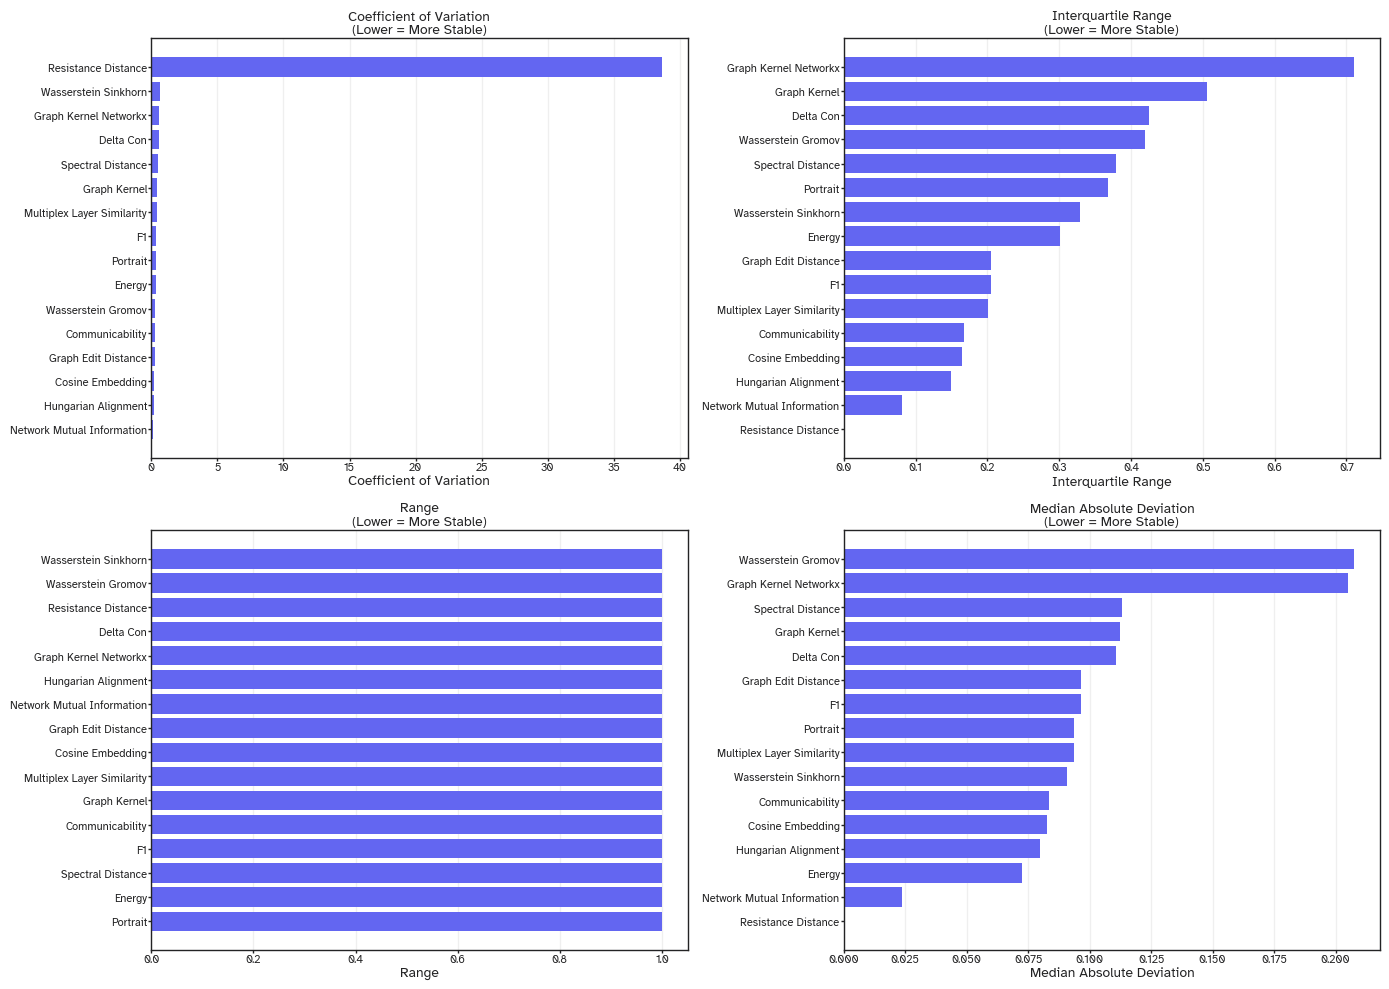


COMPREHENSIVE SUMMARY

FINAL RANKING (by composite score):
                            consensus_mean  consensus_median  inter_method_agreement  pc1_correlation  stability  composite_score  rank
energy                            1.000000          1.000000                1.000000         0.326799   0.417853         0.748930   1.0
portrait                          0.637644          0.718654                0.785021         0.937621   0.355160         0.686820   2.0
spectral_distance                 0.619649          0.710525                0.771002         0.917951   0.248131         0.653451   3.0
network_mutual_information        0.626317          0.316402                0.688376         0.625120   1.000000         0.651243   4.0
wasserstein_gromov                0.680126          0.571813                0.550917         0.538940   0.465055         0.561370   5.0
cosine_embedding                  0.482084          0.788174                0.565112         0.168566   0.592959         0.5

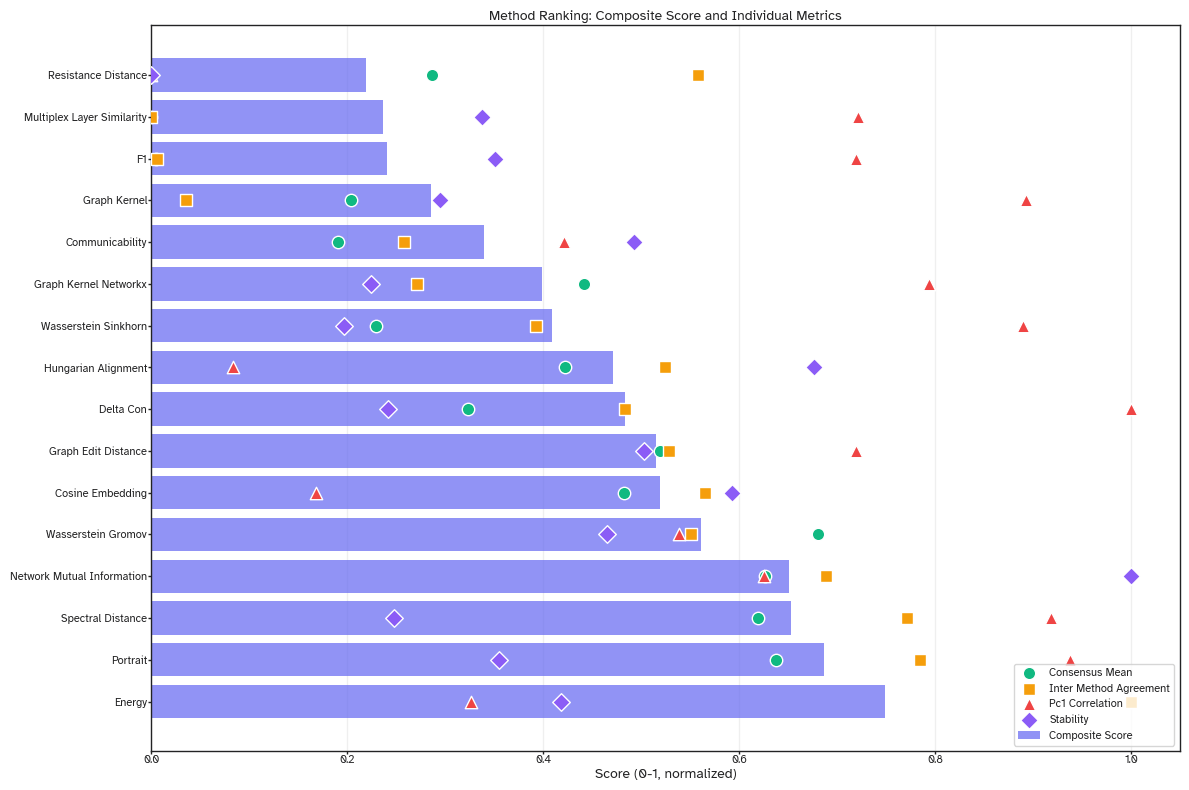


Analysis complete! All outputs saved to: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/method_evaluation

Key insights:
1. Best overall method: energy
2. Top 3 methods: energy, portrait, spectral_distance
3. Check '/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/lexis_data/03_no_ring_sweeps_animal_0/method_evaluation/method_ranking_summary.csv' for details


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Configuration"
output_path = Path(base_path) / "method_evaluation"
output_path.mkdir(exist_ok=True)

all_methods = [
    "portrait", "energy", "spectral_distance", "f1", "communicability",
    "graph_kernel", "multiplex_layer_similarity", "cosine_embedding",
    "graph_edit_distance", "network_mutual_information", "hungarian_alignment",
    "graph_kernel_networkx", "delta_con", "resistance_distance",
    "wasserstein_gromov", "wasserstein_sinkhorn"
]

def load_all_methods():
    """Load and combine all method data."""
    all_data_list = []
    loaded_methods = []
    
    for method in all_methods:
        path = f"{base_path}/summary_indiv_{method}_for_exp_{experiment_name}.csv"
        try:
            df = pd.read_csv(path)
            metric_cols = [col for col in df.columns 
                          if col not in ["eta", "gamma", "network_index", "filename", "id"]]
            if metric_cols:
                df['metric_value'] = df[metric_cols[0]]
                df['method'] = method
                all_data_list.append(df[['eta', 'gamma', 'id', 'metric_value', 'method']])
                loaded_methods.append(method)
                print(f"  ✓ Loaded {method}")
        except FileNotFoundError:
            print(f"  ✗ File not found for {method}")
    
    all_data = pd.concat(all_data_list, ignore_index=True)
    
    # Create wide format
    wide_data = all_data.pivot_table(
        index=['eta', 'gamma', 'id'],
        columns='method',
        values='metric_value'
    ).reset_index()
    
    return wide_data, loaded_methods


def normalize_methods(data, methods):
    """Normalize each method to [0, 1] range."""
    normalized = data.copy()
    for method in methods:
        min_val = data[method].min()
        max_val = data[method].max()
        if max_val > min_val:
            normalized[method] = (data[method] - min_val) / (max_val - min_val)
    return normalized


# ============================================================================
# STRATEGY 1: CONSENSUS-BASED APPROACHES
# ============================================================================

def consensus_approaches(data, methods):
    """Calculate different consensus measures."""
    print("\n" + "="*70)
    print("STRATEGY 1: CONSENSUS-BASED GROUND TRUTH")
    print("="*70)
    
    results = {}
    
    # Normalize first
    norm_data = normalize_methods(data, methods)
    
    # 1. Mean consensus (ensemble average)
    norm_data['consensus_mean'] = norm_data[methods].mean(axis=1)
    
    # 2. Median consensus (robust to outliers)
    norm_data['consensus_median'] = norm_data[methods].median(axis=1)
    
    # 3. Trimmed mean (remove top/bottom 10%)
    norm_data['consensus_trimmed'] = norm_data[methods].apply(
        lambda x: stats.trim_mean(x.dropna(), 0.1), axis=1
    )
    
    # Calculate correlations with each consensus
    for consensus_type in ['mean', 'median', 'trimmed']:
        col = f'consensus_{consensus_type}'
        print(f"\nCorrelations with {consensus_type.upper()} consensus:")
        corrs = {}
        for method in methods:
            corr = norm_data[method].corr(norm_data[col])
            corrs[method] = corr
            print(f"  {method:30s}: {corr:.4f}")
        results[consensus_type] = corrs
    
    # Save
    consensus_df = pd.DataFrame(results).T
    consensus_df.to_csv(output_path / 'consensus_correlations.csv')
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for idx, consensus_type in enumerate(['mean', 'median', 'trimmed']):
        corrs = results[consensus_type]
        sorted_methods = sorted(corrs.keys(), key=lambda x: corrs[x], reverse=True)
        values = [corrs[m] for m in sorted_methods]
        
        axes[idx].barh(range(len(sorted_methods)), values, color='#6366f1')
        axes[idx].set_yticks(range(len(sorted_methods)))
        axes[idx].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods], fontsize=8)
        axes[idx].set_xlabel('Correlation', fontsize=10)
        axes[idx].set_title(f'{consensus_type.title()} Consensus') # , fontsize=12, fontweight='bold')
        axes[idx].axvline(x=np.mean(values), color='red', linestyle='--', alpha=0.5, label='Mean')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].legend()
    
    plt.tight_layout()
    plt.savefig(output_path / 'consensus_correlations.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    return norm_data, results


# ============================================================================
# STRATEGY 2: INTER-METHOD AGREEMENT
# ============================================================================

def inter_method_agreement(data, methods):
    """Calculate how well each method agrees with all others."""
    print("\n" + "="*70)
    print("STRATEGY 2: INTER-METHOD AGREEMENT")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Calculate average correlation with all other methods
    agreement_scores = {}
    for method1 in methods:
        corrs = []
        for method2 in methods:
            if method1 != method2:
                corr = norm_data[method1].corr(norm_data[method2])
                if not np.isnan(corr):
                    corrs.append(corr)
        agreement_scores[method1] = np.mean(corrs) if corrs else 0
    
    print("\nAverage agreement with other methods:")
    for method, score in sorted(agreement_scores.items(), key=lambda x: x[1], reverse=True):
        print(f"  {method:30s}: {score:.4f}")
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    sorted_methods = sorted(agreement_scores.keys(), key=lambda x: agreement_scores[x], reverse=True)
    values = [agreement_scores[m] for m in sorted_methods]
    
    colors = ['#10b981' if v > np.mean(values) else '#6366f1' for v in values]
    ax.barh(range(len(sorted_methods)), values, color=colors)
    ax.set_yticks(range(len(sorted_methods)))
    ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    ax.set_xlabel('Average Correlation with Other Methods') # , fontsize=11)
    ax.set_title('Inter-Method Agreement Scores\n(Higher = More consensus with other methods)') 
                #  fontsize=13, fontweight='bold', pad=15)
    ax.axvline(x=np.mean(values), color='red', linestyle='--', alpha=0.5, label=f'Mean = {np.mean(values):.3f}')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(output_path / 'inter_method_agreement.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    pd.DataFrame({'method': list(agreement_scores.keys()), 
                  'agreement_score': list(agreement_scores.values())}).to_csv(
        output_path / 'inter_method_agreement.csv', index=False)
    
    return agreement_scores


# ============================================================================
# STRATEGY 3: PCA-BASED APPROACH
# ============================================================================

def pca_approach(data, methods):
    """Use PCA to find the main component across methods."""
    print("\n" + "="*70)
    print("STRATEGY 3: PCA-BASED APPROACH")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    # Prepare data (remove NaNs)
    X = norm_data[methods].dropna()
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"\nExplained variance by component:")
    for i, var in enumerate(pca.explained_variance_ratio_[:5]):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    print(f"  Cumulative (first 3): {pca.explained_variance_ratio_[:3].sum():.4f}")
    
    # Loadings (how much each method contributes to PC1)
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(methods))],
        index=methods
    )
    
    print(f"\nPC1 Loadings (main component):")
    for method, loading in loadings['PC1'].abs().sort_values(ascending=False).items():
        print(f"  {method:30s}: {loadings.loc[method, 'PC1']:7.4f} (|{loading:.4f}|)")
    
    # Save
    loadings.to_csv(output_path / 'pca_loadings.csv')
    
    # Plot loadings
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PC1 loadings
    sorted_methods = loadings['PC1'].abs().sort_values(ascending=False).index
    values = [loadings.loc[m, 'PC1'] for m in sorted_methods]
    colors = ['#10b981' if v > 0 else '#ef4444' for v in values]
    
    axes[0].barh(range(len(sorted_methods)), values, color=colors)
    axes[0].set_yticks(range(len(sorted_methods)))
    axes[0].set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    axes[0].set_xlabel('PC1 Loading') # , fontsize=11)
    axes[0].set_title(f'PC1 Loadings (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)') # , 
                        # fontsize=12, fontweight='bold')
    axes[0].axvline(x=0, color='black', linewidth=0.8)
    axes[0].grid(axis='x', alpha=0.3)
    
    # Scree plot
    axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                 pca.explained_variance_ratio_, 'o-', linewidth=2, markersize=8, color='#6366f1')
    axes[1].set_xlabel('Principal Component') # , fontsize=11)
    axes[1].set_ylabel('Explained Variance Ratio') # , fontsize=11)
    axes[1].set_title('Scree Plot') # , fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'pca_analysis.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    # Calculate correlation of each method with PC1
    pc1_scores = X_pca[:, 0]
    pc1_correlations = {}
    for i, method in enumerate(methods):
        pc1_correlations[method] = np.corrcoef(X[method], pc1_scores)[0, 1]
    
    return loadings, pca, pc1_correlations


# ============================================================================
# STRATEGY 4: COEFFICIENT OF VARIATION (STABILITY)
# ============================================================================

def stability_analysis(data, methods):
    """Analyze which methods have more stable/consistent values."""
    print("\n" + "="*70)
    print("STRATEGY 4: STABILITY ANALYSIS")
    print("="*70)
    
    norm_data = normalize_methods(data, methods)
    
    stability_metrics = {}
    
    for method in methods:
        values = norm_data[method].dropna()
        stability_metrics[method] = {
            'cv': values.std() / values.mean() if values.mean() != 0 else np.inf,  # Coefficient of variation
            'iqr': values.quantile(0.75) - values.quantile(0.25),  # Interquartile range
            'range': values.max() - values.min(),
            'mad': np.median(np.abs(values - values.median()))  # Median absolute deviation
        }
    
    print("\nStability metrics (lower = more stable/consistent):")
    print("\nCoefficient of Variation (CV):")
    for method, metrics in sorted(stability_metrics.items(), key=lambda x: x[1]['cv']):
        print(f"  {method:30s}: {metrics['cv']:.4f}")
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for idx, (metric_name, ylabel) in enumerate([
        ('cv', 'Coefficient of Variation'),
        ('iqr', 'Interquartile Range'),
        ('range', 'Range'),
        ('mad', 'Median Absolute Deviation')
    ]):
        ax = axes[idx // 2, idx % 2]
        
        sorted_methods = sorted(stability_metrics.keys(), 
                               key=lambda x: stability_metrics[x][metric_name])
        values = [stability_metrics[m][metric_name] for m in sorted_methods]
        
        ax.barh(range(len(sorted_methods)), values, color='#6366f1')
        ax.set_yticks(range(len(sorted_methods)))
        ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods], fontsize=8)
        ax.set_xlabel(ylabel) # , fontsize=10)
        ax.set_title(f'{ylabel}\n(Lower = More Stable)') # , fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'stability_analysis.png', dpi=300, bbox_inches='tight')
    # plt.close() 
    plt.show()
    
    pd.DataFrame(stability_metrics).T.to_csv(output_path / 'stability_metrics.csv')
    
    return stability_metrics


# ============================================================================
# SUMMARY REPORT
# ============================================================================

def create_summary_report(consensus_results, agreement_scores, pc1_correlations, stability_metrics):
    """Create a comprehensive summary ranking methods."""
    print("\n" + "="*70)
    print("COMPREHENSIVE SUMMARY")
    print("="*70)
    
    methods = list(agreement_scores.keys())
    
    summary = pd.DataFrame(index=methods)
    
    # Add consensus correlations
    summary['consensus_mean'] = [consensus_results['mean'][m] for m in methods]
    summary['consensus_median'] = [consensus_results['median'][m] for m in methods]
    
    # Add inter-method agreement
    summary['inter_method_agreement'] = [agreement_scores[m] for m in methods]
    
    # Add PC1 correlation (absolute value)
    summary['pc1_correlation'] = [abs(pc1_correlations[m]) for m in methods]
    
    # Add stability (inverse CV, so higher = better)
    summary['stability'] = [1 / (stability_metrics[m]['cv'] + 0.01) for m in methods]
    
    # Normalize all metrics to [0, 1]
    for col in summary.columns:
        min_val = summary[col].min()
        max_val = summary[col].max()
        if max_val > min_val:
            summary[col] = (summary[col] - min_val) / (max_val - min_val)
    
    # Calculate composite score (equal weighting)
    summary['composite_score'] = summary.mean(axis=1)
    
    # Rank
    summary['rank'] = summary['composite_score'].rank(ascending=False)
    
    # Sort by composite score
    summary = summary.sort_values('composite_score', ascending=False)
    
    print("\nFINAL RANKING (by composite score):")
    print(summary.to_string())
    
    summary.to_csv(output_path / 'method_ranking_summary.csv')
    
    # Visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sorted_methods = summary.index
    y_pos = range(len(sorted_methods))
    
    ax.barh(y_pos, summary['composite_score'], color='#6366f1', alpha=0.7, label='Composite Score')
    
    # Add individual metric markers
    for col, marker, color in [
        ('consensus_mean', 'o', '#10b981'),
        ('inter_method_agreement', 's', '#f59e0b'),
        ('pc1_correlation', '^', '#ef4444'),
        ('stability', 'D', '#8b5cf6')
    ]:
        ax.scatter(summary[col], y_pos, marker=marker, s=80, 
                  color=color, label=col.replace('_', ' ').title(), 
                  edgecolors='white', linewidth=1, zorder=3)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels([m.replace('_', ' ').title() for m in sorted_methods]) # , fontsize=9)
    ax.set_xlabel('Score (0-1, normalized)') # , fontsize=11)
    ax.set_title('Method Ranking: Composite Score and Individual Metrics') # , 
                # fontsize=13, fontweight='bold', pad=15)
    ax.legend(loc='lower right') # , fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path / 'method_ranking_summary.png', dpi=300, bbox_inches='tight')
    # plt.close()
    plt.show()
    
    return summary


def main():
    print("="*70)
    print("COMPREHENSIVE METHOD EVALUATION")
    print("="*70)
    
    # Load data
    print("\nLoading data...")
    data, methods = load_all_methods()
    print(f"\nLoaded {len(methods)} methods with {len(data)} networks")
    
    # Run all strategies
    norm_data, consensus_results = consensus_approaches(data, methods)
    agreement_scores = inter_method_agreement(data, methods)
    loadings, pca_model, pc1_correlations = pca_approach(data, methods)
    stability_metrics = stability_analysis(data, methods)
    
    # Create summary
    summary = create_summary_report(consensus_results, agreement_scores, 
                                   pc1_correlations, stability_metrics)
    
    print(f"\n{'='*70}")
    print(f"Analysis complete! All outputs saved to: {output_path}")
    print(f"{'='*70}")
    print("\nKey insights:")
    print(f"1. Best overall method: {summary.index[0]}")
    print(f"2. Top 3 methods: {', '.join(summary.index[:3])}")
    print(f"3. Check '{output_path}/method_ranking_summary.csv' for details")

if __name__ == "__main__":
    main()